# EDA - Goal 2: Analisis Kerentanan Ekonomi Wilayah Koperasi
**Wilayah Studi:** Kabupaten Banyumas, Jawa Tengah  
**Tujuan:** Menganalisis kerentanan ekonomi wilayah koperasi, mengidentifikasi koperasi risiko tinggi, dan zona prioritas intervensi pemerintah

| Variabel | File | Sumber | Keterangan |
|---|---|---|---|
| Koperasi KDMP | KDMP Banyumas.csv | simkopdes.go.id | 117 koperasi, 23 kecamatan |
| Pemukiman | pemukiman.geojson | OSM | 481.032 bangunan, ada kolom area_m2 |
| Fasilitas Kesehatan | faskes.geojson | OSM | 45 faskes, mix Point & Polygon |
| Fasilitas Pendidikan | pendidikan.geojson | OSM | 216 sekolah, mix Point/Polygon/MultiPolygon |
| Jaringan Jalan | jaringan jalan.geojson | OSM | 641 segmen, total ~529 km, ada kolom length |
| Kepadatan Penduduk | kepadatan penduduk.geojson | OSM H3 | 300 hexagon, kolom: building_count, density, kategori_density |
| Kemiskinan | kemiskinan.csv | Meta RWI-HDX | sep=; 24 kecamatan, kolom: indeks_kemiskinan_mean, interpretasi |
| Pengangguran | pengangguran.csv | BPS | 27 kecamatan, kolom: tingkat_pengangguran, jumlah_pengangguran |

## 1. Install & Import Library

In [1]:
%pip install geopandas folium mapclassify matplotlib seaborn scipy -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install "numpy<2" "pandas<3" "pyarrow<20" --force-reinstall

  Obtaining dependency information for numpy<2 from https://files.pythonhosted.org/packages/3f/6b/5610004206cf7f8e7ad91c5a85a8c71b2f2f8051a0c0c4d5916b76d6cbb2/numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.0 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 406.4 kB/s eta 0:00:00
  Obtaining dependency information for pandas<3 from https://files.pythonhosted.org/packages/8e/59/712db1d7040520de7a4965df15b774348980e6df45c129b8c64d0dbe74ef/pandas-2.3.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for pyarrow<20 from https://files.pythonhosted.org/packages/ff/77/e62aebd343238863f2c9f080ad2ef6ace25c919c6ab383436b5b81cbeef7/pyarrow-19.0.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for python-dateutil>=2.8.2 from h

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.75 requires requests_mock, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
conda-repo-cli 1.0.75 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.75 requires python-dateutil==2.8.2, but you have python-dateutil 2.9.0.post0 which is incompatible.
conda-repo-cli 1.0.75 requires PyYAML==6.0.1, but you have pyyaml 6.0 which is incompatible.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.


In [32]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
from scipy.spatial import cKDTree
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print('Library siap!')

Library siap!


## 2. Load Data

In [4]:
import os
DATA_DIR = r"D:\semester 6\Big Data IOT\koperasi\data"

koperasi     = pd.read_csv(os.path.join(DATA_DIR, "KDMP Banyumas.csv"))
pemukiman    = gpd.read_file(os.path.join(DATA_DIR, "pemukiman.geojson"))
faskes       = gpd.read_file(os.path.join(DATA_DIR, "faskes.geojson"))
pendidikan   = gpd.read_file(os.path.join(DATA_DIR, "pendidikan.geojson"))
jalan        = gpd.read_file(os.path.join(DATA_DIR, "jaringan jalan.geojson"))
kepadatan    = gpd.read_file(os.path.join(DATA_DIR, "kepadatan penduduk.geojson"))
kemiskinan   = pd.read_csv(os.path.join(DATA_DIR, "kemiskinan.csv"), sep=';', encoding='utf-8-sig')
pengangguran = pd.read_csv(os.path.join(DATA_DIR, "pengangguran.csv"))

print('Semua data berhasil di-load!')
print(f'  Koperasi      : {len(koperasi)} baris')
print(f'  Pemukiman     : {len(pemukiman):,} bangunan')
print(f'  Faskes        : {len(faskes)} fitur')
print(f'  Pendidikan    : {len(pendidikan)} fitur')
print(f'  Jalan         : {len(jalan)} segmen')
print(f'  Kepadatan     : {len(kepadatan)} hexagon H3')
print(f'  Kemiskinan    : {len(kemiskinan)} kecamatan')
print(f'  Pengangguran  : {len(pengangguran)} kecamatan')

Semua data berhasil di-load!
  Koperasi      : 117 baris
  Pemukiman     : 481,032 bangunan
  Faskes        : 45 fitur
  Pendidikan    : 216 fitur
  Jalan         : 641 segmen
  Kepadatan     : 300 hexagon H3
  Kemiskinan    : 24 kecamatan
  Pengangguran  : 27 kecamatan


## 3. Preprocessing
### 3.1 Koperasi - Parse Koordinat ke GeoDataFrame

In [6]:
# Bersihkan spasi yang tidak wajar di koordinat (contoh: "- 7.xxx" → "-7.xxx")
koperasi['Koordinat'] = koperasi['Koordinat'].str.replace(r'-\s+', '-', regex=True)

# Parse koordinat
koperasi[['lat', 'lon']] = koperasi['Koordinat'].str.split(',', expand=True).astype(float)

gdf_koperasi = gpd.GeoDataFrame(
    koperasi,
    geometry=gpd.points_from_xy(koperasi['lon'], koperasi['lat']),
    crs='EPSG:4326'
)
print(f'Koperasi berhasil dikonversi ke GeoDataFrame: {len(gdf_koperasi)} titik')
print(f'Kategori: {gdf_koperasi["Kategori Pembangunan"].value_counts().to_dict()}')

Koperasi berhasil dikonversi ke GeoDataFrame: 117 titik
Kategori: {'100%': 72, '> 75%': 45}


### 3.2 Faskes - Gabung Kolom Jenis & Konversi Polygon ke Centroid

In [7]:
# Kolom 'amenity' dan 'healthcare' keduanya ada, gabung ke kolom 'jenis'
faskes['jenis'] = faskes['amenity'].combine_first(faskes['healthcare'])
faskes['jenis'] = faskes['jenis'].str.split(';').str[0]  # ambil nilai pertama jika ada semicolon

# Konversi polygon ke centroid agar bisa dihitung jarak ke titik
faskes_pt = faskes.copy()
mask = faskes_pt.geometry.type.isin(['Polygon', 'MultiPolygon'])
faskes_pt.loc[mask, 'geometry'] = faskes_pt.loc[mask].geometry.centroid
faskes_pt = faskes_pt.to_crs('EPSG:4326')

print('Jenis faskes:', faskes['jenis'].value_counts().to_dict())
print('Geom type asal:', faskes.geometry.type.value_counts().to_dict())

Jenis faskes: {'hospital': 28, 'clinic': 9, 'pharmacy': 4, 'dentist': 2, 'doctors': 1, 'blood_donation': 1}
Geom type asal: {'Polygon': 29, 'Point': 16}


### 3.3 Pendidikan - Konversi Polygon ke Centroid

In [8]:
pendidikan_pt = pendidikan.copy()
mask = pendidikan_pt.geometry.type.isin(['Polygon', 'MultiPolygon'])
pendidikan_pt.loc[mask, 'geometry'] = pendidikan_pt.loc[mask].geometry.centroid
pendidikan_pt = pendidikan_pt.to_crs('EPSG:4326')

print('Jenis pendidikan:', pendidikan['amenity'].value_counts().to_dict())

Jenis pendidikan: {'school': 176, 'university': 24, 'kindergarten': 12, 'college': 4}


### 3.4 Jalan - Bersihkan Tipe Highway

In [9]:
# Beberapa nilai highway berisi list, ambil nilai pertama
jalan['highway_clean'] = jalan['highway'].astype(str)
jalan['highway_clean'] = jalan['highway_clean'].str.replace(r"[\[\]']", '', regex=True)
jalan['highway_clean'] = jalan['highway_clean'].str.split(',').str[0].str.strip()

print('Tipe jalan:', jalan['highway_clean'].value_counts().to_dict())
print(f'Total panjang jalan: {jalan["length"].sum()/1000:.1f} km')

Tipe jalan: {'tertiary': 247, 'secondary': 226, 'primary': 144, 'tertiary_link': 16, 'secondary_link': 4, 'primary_link': 2, 'tertiary secondary': 1, 'secondary tertiary': 1}
Total panjang jalan: 529.6 km


### 3.5 Kemiskinan - Drop 'Tidak Diketahui' & Fix Tipe Data

In [10]:
kemiskinan = kemiskinan[kemiskinan['kecamatan'] != 'Tidak Diketahui'].copy()
kemiskinan['indeks_kemiskinan_mean'] = pd.to_numeric(
    kemiskinan['indeks_kemiskinan_mean'], errors='coerce'
)
print(f'Kemiskinan setelah cleaning: {len(kemiskinan)} kecamatan')
print('Distribusi interpretasi:', kemiskinan['interpretasi'].value_counts().to_dict())

Kemiskinan setelah cleaning: 23 kecamatan
Distribusi interpretasi: {'Sejahtera': 9, 'Miskin': 6, 'Sangat Miskin': 4, 'Menengah': 4}


---
## 4. EDA Per Variabel
### 4.1 Koperasi KDMP

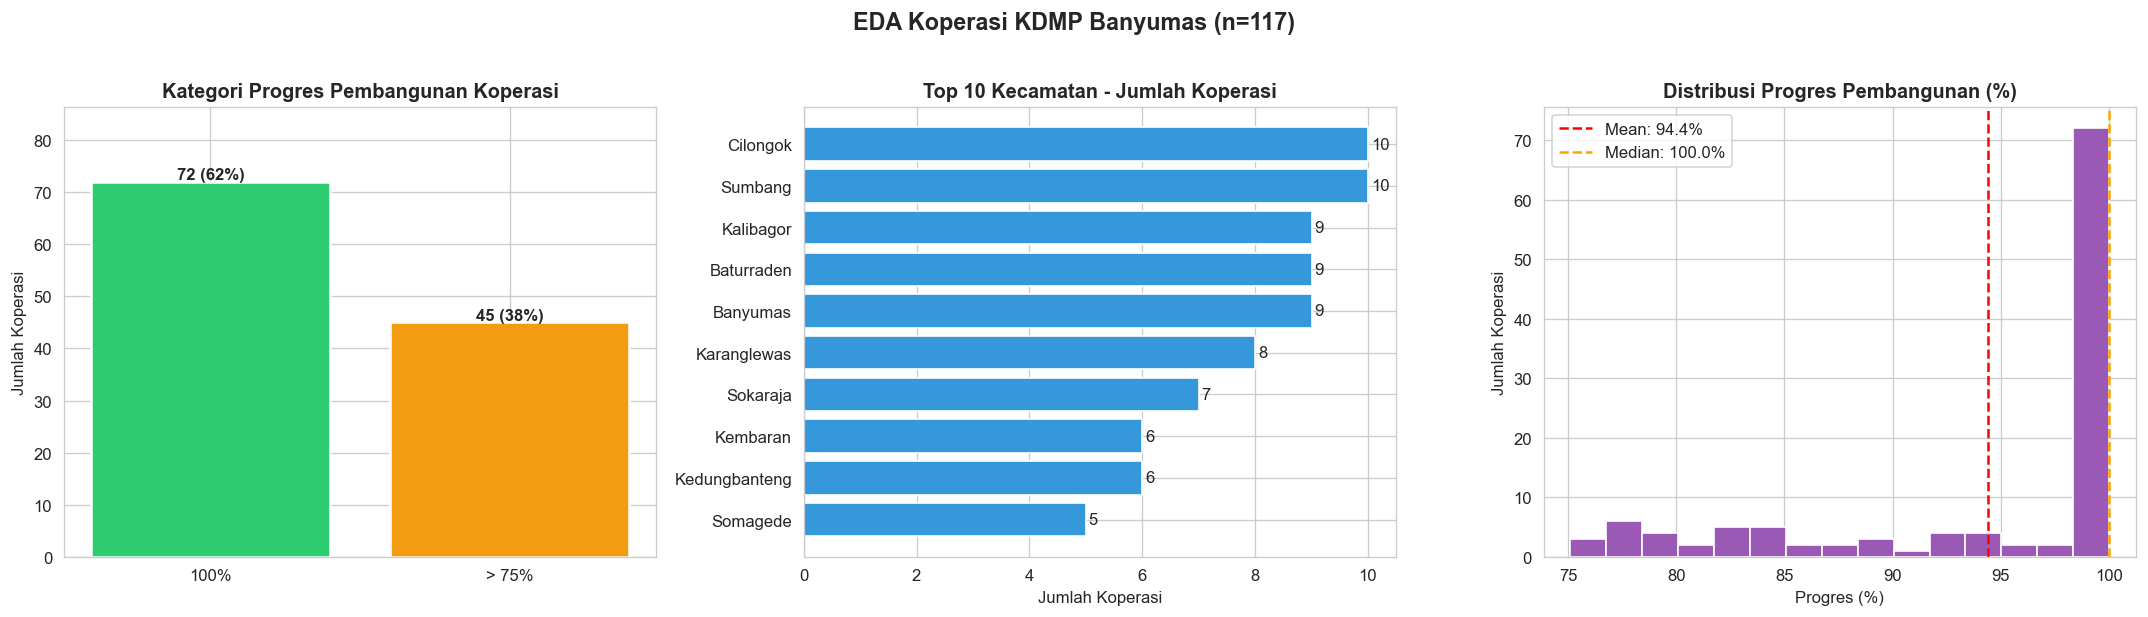

count    117.00
mean      94.40
std        8.22
min       75.11
25%       89.06
50%      100.00
75%      100.00
max      100.00
Name: Progres Pembangunan (%), dtype: float64


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Kategori pembangunan
kat = gdf_koperasi['Kategori Pembangunan'].value_counts()
bars = axes[0].bar(kat.index, kat.values, color=['#2ecc71','#f39c12'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, kat.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val} ({val/len(gdf_koperasi)*100:.0f}%)', ha='center', fontweight='bold')
axes[0].set_title('Kategori Progres Pembangunan Koperasi', fontweight='bold')
axes[0].set_ylabel('Jumlah Koperasi')
axes[0].set_ylim(0, max(kat.values) * 1.2)

# Top 10 kecamatan
top_kec = gdf_koperasi['Kecamatan'].value_counts().head(10)
axes[1].barh(top_kec.index[::-1], top_kec.values[::-1], color='#3498db', edgecolor='white')
axes[1].set_title('Top 10 Kecamatan - Jumlah Koperasi', fontweight='bold')
axes[1].set_xlabel('Jumlah Koperasi')
for i, v in enumerate(top_kec.values[::-1]):
    axes[1].text(v + 0.05, i, str(v), va='center')

# Histogram progres
axes[2].hist(gdf_koperasi['Progres Pembangunan (%)'], bins=15, color='#9b59b6', edgecolor='white')
axes[2].axvline(gdf_koperasi['Progres Pembangunan (%)'].mean(), color='red', linestyle='--',
               label=f'Mean: {gdf_koperasi["Progres Pembangunan (%)"].mean():.1f}%')
axes[2].axvline(gdf_koperasi['Progres Pembangunan (%)'].median(), color='orange', linestyle='--',
               label=f'Median: {gdf_koperasi["Progres Pembangunan (%)"].median():.1f}%')
axes[2].set_title('Distribusi Progres Pembangunan (%)', fontweight='bold')
axes[2].set_xlabel('Progres (%)')
axes[2].set_ylabel('Jumlah Koperasi')
axes[2].legend()

plt.suptitle('EDA Koperasi KDMP Banyumas (n=117)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_koperasi.png', bbox_inches='tight')
plt.show()
print(gdf_koperasi['Progres Pembangunan (%)'].describe().round(2))

### 4.2 Pemukiman (Building Footprint)

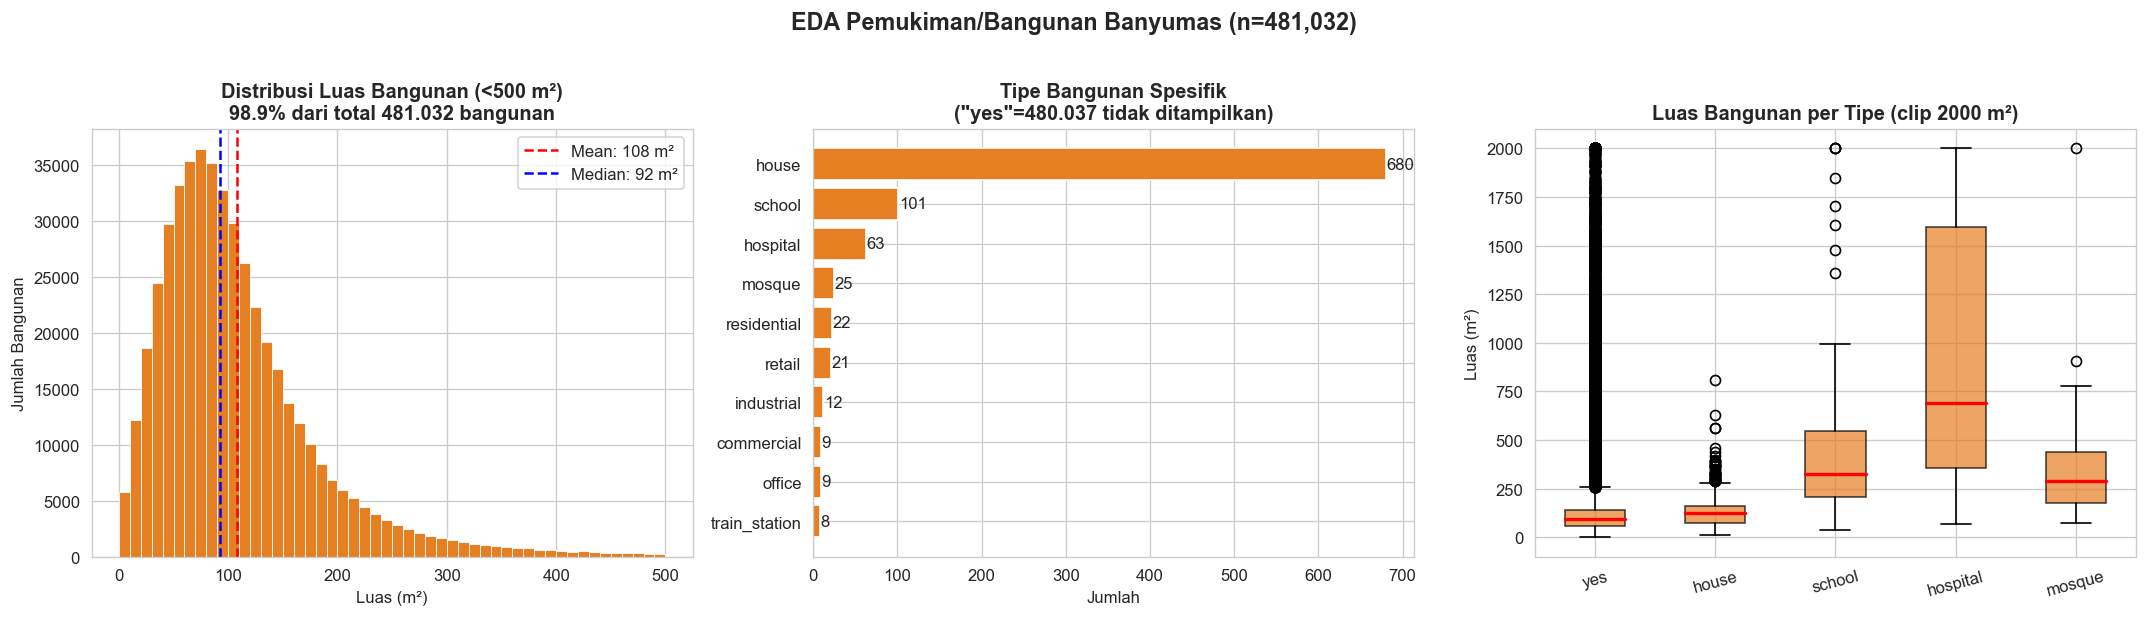

count    481032.00
mean        117.85
std         156.40
min           0.09
25%          59.02
50%          92.97
75%         139.86
max       23329.41
Name: area_m2, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi luas (filter <500m2 = 98.9% data)
area_filt = pemukiman['area_m2'][pemukiman['area_m2'] < 500]
axes[0].hist(area_filt, bins=50, color='#e67e22', edgecolor='white', linewidth=0.5)
axes[0].axvline(area_filt.mean(), color='red', linestyle='--', label=f'Mean: {area_filt.mean():.0f} m²')
axes[0].axvline(area_filt.median(), color='blue', linestyle='--', label=f'Median: {area_filt.median():.0f} m²')
axes[0].set_title('Distribusi Luas Bangunan (<500 m²)\n98.9% dari total 481.032 bangunan', fontweight='bold')
axes[0].set_xlabel('Luas (m²)')
axes[0].set_ylabel('Jumlah Bangunan')
axes[0].legend()

# Tipe bangunan spesifik (exclude 'yes' yang dominan 480.037)
top_type = pemukiman[pemukiman['building'] != 'yes']['building'].value_counts().head(10)
axes[1].barh(top_type.index[::-1], top_type.values[::-1], color='#e67e22', edgecolor='white')
axes[1].set_title('Tipe Bangunan Spesifik\n("yes"=480.037 tidak ditampilkan)', fontweight='bold')
axes[1].set_xlabel('Jumlah')
for i, v in enumerate(top_type.values[::-1]):
    axes[1].text(v + 0.5, i, str(v), va='center')

# Boxplot luas per tipe bangunan
top5 = ['yes','house','school','hospital','mosque']
data_box = [pemukiman[pemukiman['building']==t]['area_m2'].clip(upper=2000).values for t in top5]
axes[2].boxplot(data_box, labels=top5, patch_artist=True,
               boxprops=dict(facecolor='#e67e22', alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Luas Bangunan per Tipe (clip 2000 m²)', fontweight='bold')
axes[2].set_ylabel('Luas (m²)')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle(f'EDA Pemukiman/Bangunan Banyumas (n={len(pemukiman):,})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_pemukiman.png', bbox_inches='tight')
plt.show()
print(pemukiman['area_m2'].describe().round(2))

### 4.3 Fasilitas Kesehatan

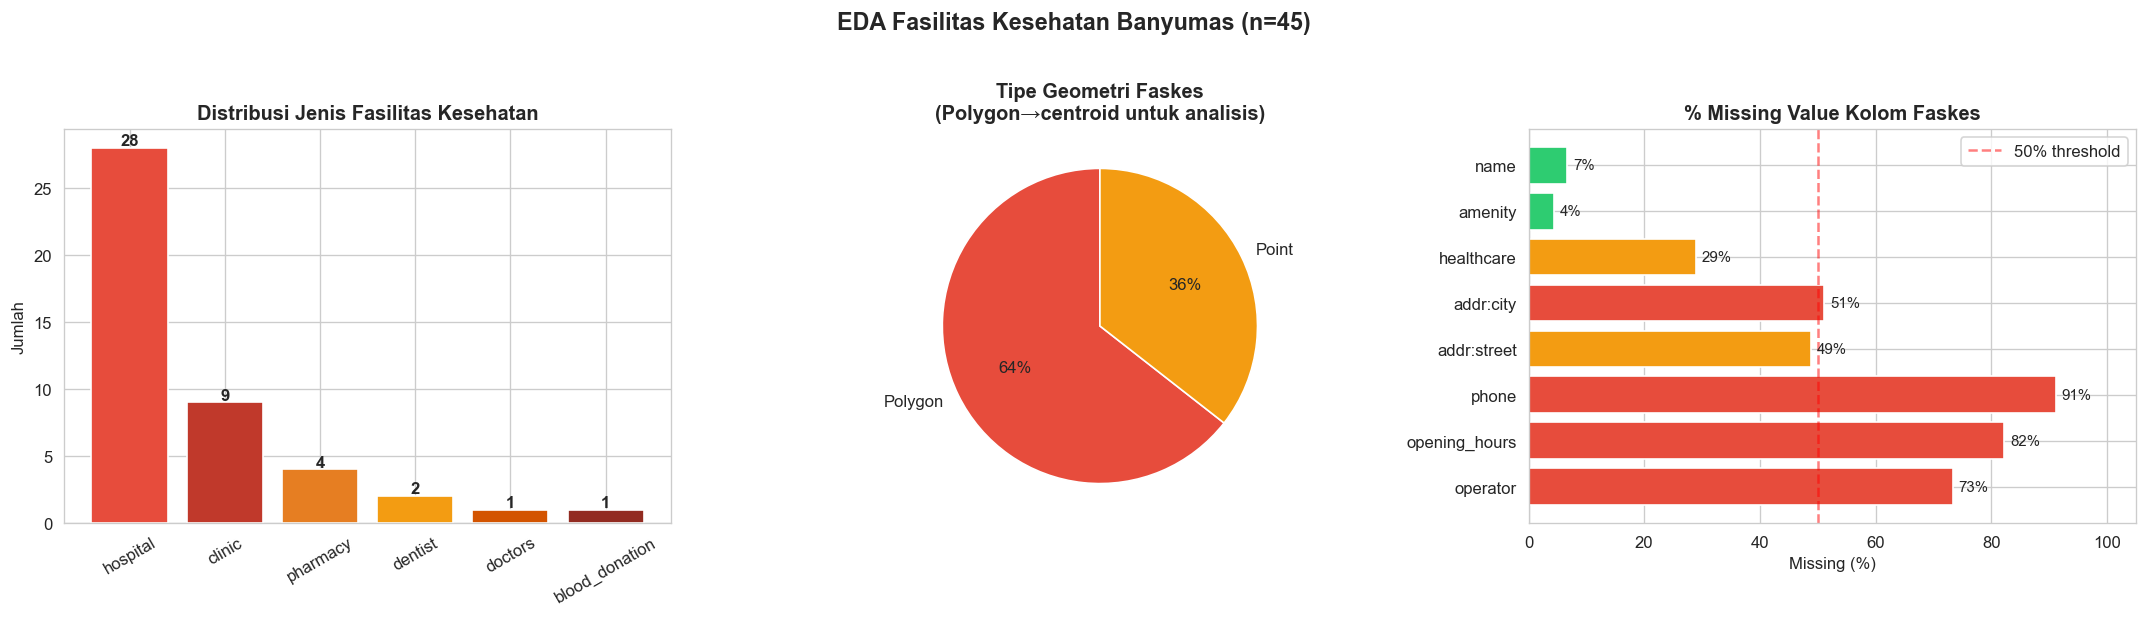

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Jenis faskes
jenis_vc = faskes['jenis'].value_counts()
colors_f = ['#e74c3c','#c0392b','#e67e22','#f39c12','#d35400','#922b21']
bars = axes[0].bar(jenis_vc.index, jenis_vc.values, color=colors_f[:len(jenis_vc)], edgecolor='white')
for bar, val in zip(bars, jenis_vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                str(val), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Jenis Fasilitas Kesehatan', fontweight='bold')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=30)

# Tipe geometri asal
geom_vc = faskes.geometry.type.value_counts()
axes[1].pie(geom_vc.values, labels=geom_vc.index, autopct='%1.0f%%',
           colors=['#e74c3c','#f39c12'], startangle=90)
axes[1].set_title('Tipe Geometri Faskes\n(Polygon→centroid untuk analisis)', fontweight='bold')

# Missing value kolom penting
cols_mv = ['name','amenity','healthcare','addr:city','addr:street','phone','opening_hours','operator']
null_pct = faskes[cols_mv].isnull().mean() * 100
bar_colors_mv = ['#e74c3c' if v>50 else '#f39c12' if v>20 else '#2ecc71' for v in null_pct.values]
axes[2].barh(null_pct.index[::-1], null_pct.values[::-1],
            color=bar_colors_mv[::-1], edgecolor='white')
axes[2].axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[2].set_title('% Missing Value Kolom Faskes', fontweight='bold')
axes[2].set_xlabel('Missing (%)')
axes[2].set_xlim(0, 105)
for i, v in enumerate(null_pct.values[::-1]):
    axes[2].text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)
axes[2].legend()

plt.suptitle(f'EDA Fasilitas Kesehatan Banyumas (n={len(faskes)})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_faskes.png', bbox_inches='tight')
plt.show()

### 4.4 Fasilitas Pendidikan

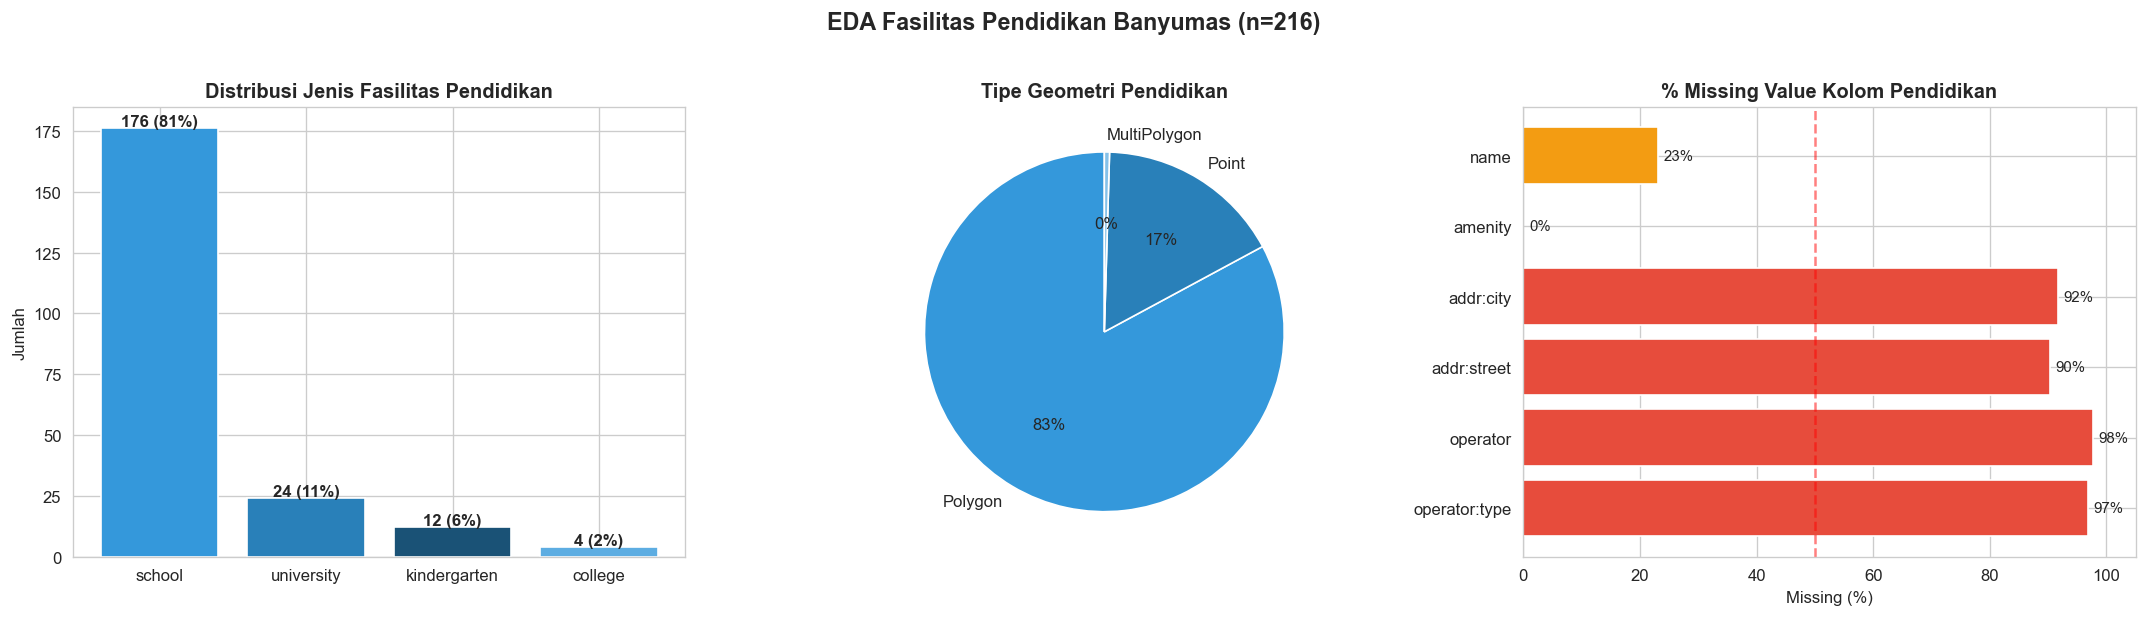

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Jenis fasilitas pendidikan
amenity_vc = pendidikan['amenity'].value_counts()
colors_e = ['#3498db','#2980b9','#1a5276','#5dade2']
bars = axes[0].bar(amenity_vc.index, amenity_vc.values, color=colors_e, edgecolor='white')
for bar, val in zip(bars, amenity_vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val} ({val/len(pendidikan)*100:.0f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribusi Jenis Fasilitas Pendidikan', fontweight='bold')
axes[0].set_ylabel('Jumlah')

# Tipe geometri
geom_vc_e = pendidikan.geometry.type.value_counts()
axes[1].pie(geom_vc_e.values, labels=geom_vc_e.index, autopct='%1.0f%%',
           colors=['#3498db','#2980b9','#85c1e9'], startangle=90)
axes[1].set_title('Tipe Geometri Pendidikan', fontweight='bold')

# Missing value kolom penting
cols_mv_e = ['name','amenity','addr:city','addr:street','operator','operator:type']
null_pct_e = pendidikan[cols_mv_e].isnull().mean() * 100
bar_colors_e = ['#e74c3c' if v>50 else '#f39c12' if v>20 else '#2ecc71' for v in null_pct_e.values]
axes[2].barh(null_pct_e.index[::-1], null_pct_e.values[::-1],
            color=bar_colors_e[::-1], edgecolor='white')
axes[2].axvline(50, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('% Missing Value Kolom Pendidikan', fontweight='bold')
axes[2].set_xlabel('Missing (%)')
axes[2].set_xlim(0, 105)
for i, v in enumerate(null_pct_e.values[::-1]):
    axes[2].text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)

plt.suptitle(f'EDA Fasilitas Pendidikan Banyumas (n={len(pendidikan)})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_pendidikan.png', bbox_inches='tight')
plt.show()

### 4.5 Jaringan Jalan

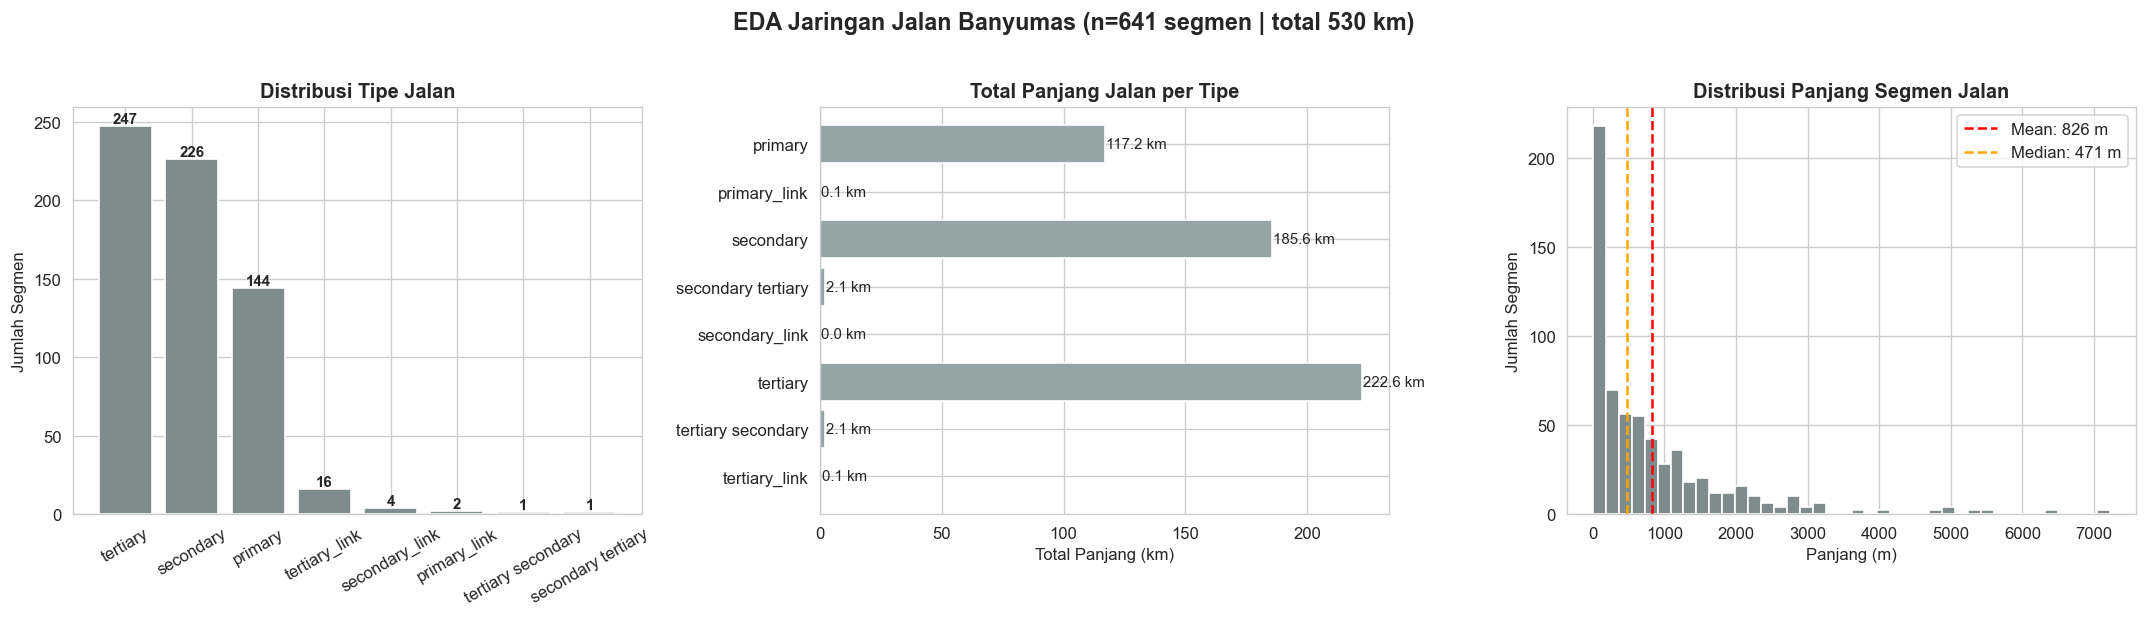

count     641.0
mean      826.3
std      1072.0
min         3.0
25%        82.0
50%       471.2
75%      1156.0
max      7225.7
Name: length, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi tipe jalan
hw_vc = jalan['highway_clean'].value_counts()
bars = axes[0].bar(hw_vc.index, hw_vc.values, color='#7f8c8d', edgecolor='white')
for bar, val in zip(bars, hw_vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Distribusi Tipe Jalan', fontweight='bold')
axes[0].set_ylabel('Jumlah Segmen')
axes[0].tick_params(axis='x', rotation=30)

# Total panjang per tipe (km)
total_len = jalan.groupby('highway_clean')['length'].sum() / 1000
axes[1].barh(total_len.index[::-1], total_len.values[::-1], color='#95a5a6', edgecolor='white')
axes[1].set_title('Total Panjang Jalan per Tipe', fontweight='bold')
axes[1].set_xlabel('Total Panjang (km)')
for i, v in enumerate(total_len.values[::-1]):
    axes[1].text(v + 0.5, i, f'{v:.1f} km', va='center', fontsize=9)

# Histogram panjang segmen
axes[2].hist(jalan['length'], bins=40, color='#7f8c8d', edgecolor='white')
axes[2].axvline(jalan['length'].mean(), color='red', linestyle='--',
               label=f'Mean: {jalan["length"].mean():.0f} m')
axes[2].axvline(jalan['length'].median(), color='orange', linestyle='--',
               label=f'Median: {jalan["length"].median():.0f} m')
axes[2].set_title('Distribusi Panjang Segmen Jalan', fontweight='bold')
axes[2].set_xlabel('Panjang (m)')
axes[2].set_ylabel('Jumlah Segmen')
axes[2].legend()

plt.suptitle(f'EDA Jaringan Jalan Banyumas (n={len(jalan)} segmen | total {jalan["length"].sum()/1000:.0f} km)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_jalan.png', bbox_inches='tight')
plt.show()
print(jalan['length'].describe().round(1))

### 4.6 Kepadatan Penduduk (H3 Hexagon)

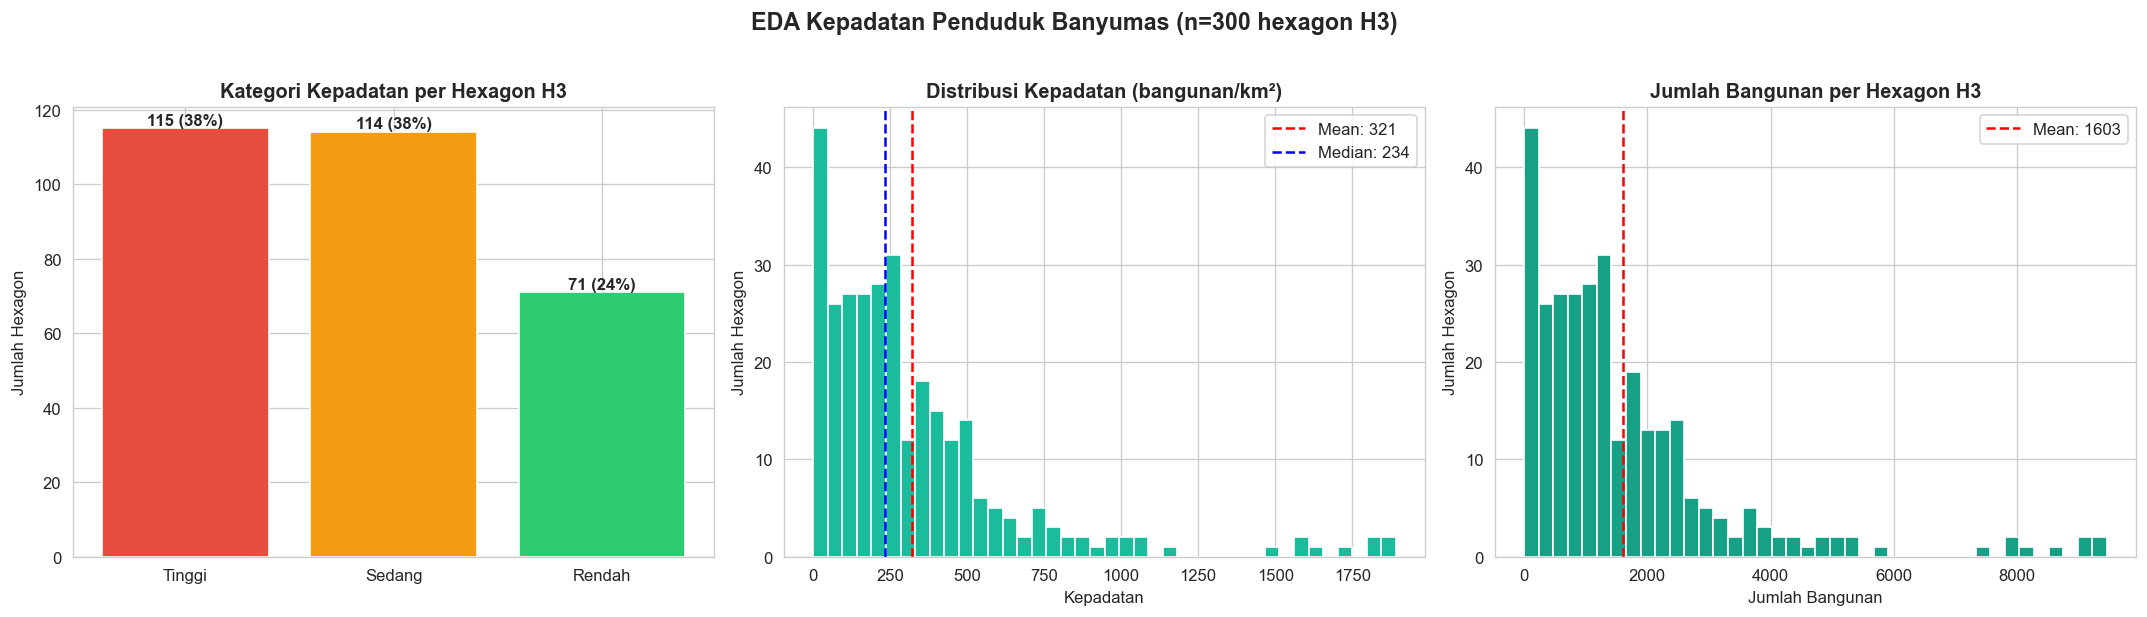

density: count     300.0
mean      320.9
std       339.2
min         0.0
25%       113.8
50%       233.5
75%       420.2
max      1892.0
Name: density, dtype: float64
building_count: count     300.0
mean     1603.5
std      1695.2
min         1.0
25%       567.8
50%      1169.0
75%      2103.5
max      9455.0
Name: building_count, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
color_kat = {'Rendah':'#2ecc71','Sedang':'#f39c12','Tinggi':'#e74c3c'}

# Kategori density per hexagon
kat_vc = kepadatan['kategori_density'].value_counts()
order_kat = ['Tinggi','Sedang','Rendah']
bars = axes[0].bar([k for k in order_kat if k in kat_vc],
                  [kat_vc.get(k,0) for k in order_kat if k in kat_vc],
                  color=[color_kat[k] for k in order_kat if k in kat_vc], edgecolor='white')
for bar, k in zip(bars, [k for k in order_kat if k in kat_vc]):
    v = kat_vc.get(k, 0)
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{v} ({v/len(kepadatan)*100:.0f}%)', ha='center', fontweight='bold')
axes[0].set_title('Kategori Kepadatan per Hexagon H3', fontweight='bold')
axes[0].set_ylabel('Jumlah Hexagon')

# Histogram density (bangunan/km2)
axes[1].hist(kepadatan['density'], bins=40, color='#1abc9c', edgecolor='white')
axes[1].axvline(kepadatan['density'].mean(), color='red', linestyle='--',
               label=f'Mean: {kepadatan["density"].mean():.0f}')
axes[1].axvline(kepadatan['density'].median(), color='blue', linestyle='--',
               label=f'Median: {kepadatan["density"].median():.0f}')
axes[1].set_title('Distribusi Kepadatan (bangunan/km²)', fontweight='bold')
axes[1].set_xlabel('Kepadatan')
axes[1].set_ylabel('Jumlah Hexagon')
axes[1].legend()

# Histogram building count per hexagon
axes[2].hist(kepadatan['building_count'], bins=40, color='#16a085', edgecolor='white')
axes[2].axvline(kepadatan['building_count'].mean(), color='red', linestyle='--',
               label=f'Mean: {kepadatan["building_count"].mean():.0f}')
axes[2].set_title('Jumlah Bangunan per Hexagon H3', fontweight='bold')
axes[2].set_xlabel('Jumlah Bangunan')
axes[2].set_ylabel('Jumlah Hexagon')
axes[2].legend()

plt.suptitle(f'EDA Kepadatan Penduduk Banyumas (n={len(kepadatan)} hexagon H3)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_kepadatan.png', bbox_inches='tight')
plt.show()
print('density:', kepadatan['density'].describe().round(1))
print('building_count:', kepadatan['building_count'].describe().round(1))

### 4.7 Kemiskinan (Meta RWI - HDX)

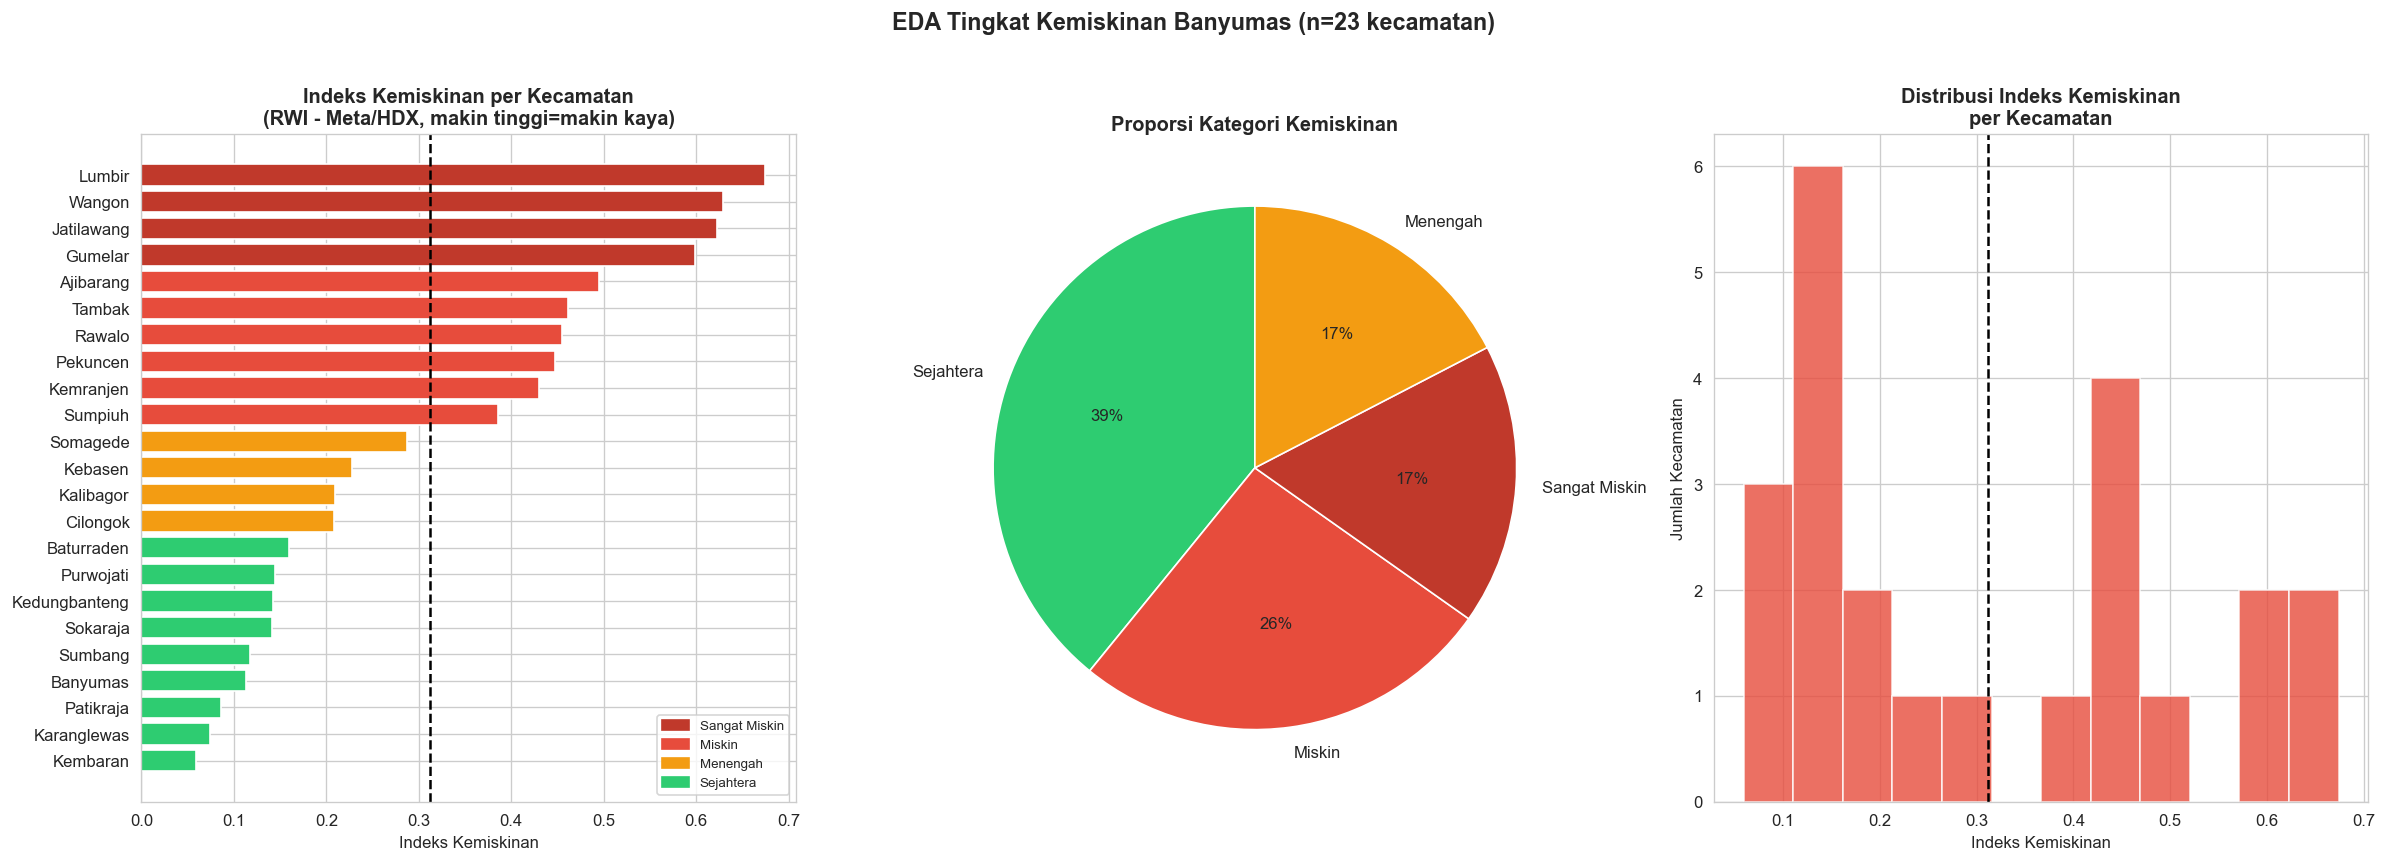

5 Kecamatan TERMISKIN:
      kecamatan  indeks_kemiskinan_mean interpretasi
23     Kembaran                0.059220    Sejahtera
22  Karanglewas                0.074458    Sejahtera
21    Patikraja                0.086061    Sejahtera
20     Banyumas                0.113490    Sejahtera
19      Sumbang                0.117138    Sejahtera


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
color_interp = {'Sangat Miskin':'#c0392b','Miskin':'#e74c3c','Menengah':'#f39c12','Sejahtera':'#2ecc71'}

# Bar horizontal per kecamatan
mis_sorted = kemiskinan.sort_values('indeks_kemiskinan_mean', ascending=True)
bar_colors_m = [color_interp.get(i,'#7f8c8d') for i in mis_sorted['interpretasi']]
axes[0].barh(mis_sorted['kecamatan'], mis_sorted['indeks_kemiskinan_mean'],
            color=bar_colors_m, edgecolor='white')
axes[0].axvline(mis_sorted['indeks_kemiskinan_mean'].mean(), color='black', linestyle='--',
               label=f'Mean: {mis_sorted["indeks_kemiskinan_mean"].mean():.3f}')
axes[0].set_title('Indeks Kemiskinan per Kecamatan\n(RWI - Meta/HDX, makin tinggi=makin kaya)',
                 fontweight='bold')
axes[0].set_xlabel('Indeks Kemiskinan')
axes[0].legend(fontsize=9)
patches_m = [mpatches.Patch(color=v, label=k) for k, v in color_interp.items()]
axes[0].legend(handles=patches_m, fontsize=8, loc='lower right')

# Pie distribusi interpretasi
interp_vc = kemiskinan['interpretasi'].value_counts()
axes[1].pie(interp_vc.values, labels=interp_vc.index, autopct='%1.0f%%',
           colors=[color_interp.get(i,'#7f8c8d') for i in interp_vc.index], startangle=90)
axes[1].set_title('Proporsi Kategori Kemiskinan', fontweight='bold')

# Histogram indeks
axes[2].hist(kemiskinan['indeks_kemiskinan_mean'], bins=12, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[2].axvline(kemiskinan['indeks_kemiskinan_mean'].mean(), color='black', linestyle='--')
axes[2].set_title('Distribusi Indeks Kemiskinan\nper Kecamatan', fontweight='bold')
axes[2].set_xlabel('Indeks Kemiskinan')
axes[2].set_ylabel('Jumlah Kecamatan')

plt.suptitle(f'EDA Tingkat Kemiskinan Banyumas (n={len(kemiskinan)} kecamatan)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_kemiskinan.png', bbox_inches='tight')
plt.show()

print('5 Kecamatan TERMISKIN:')
print(kemiskinan.sort_values('indeks_kemiskinan_mean').head(5)[['kecamatan','indeks_kemiskinan_mean','interpretasi']].to_string())

### 4.8 Pengangguran (BPS)

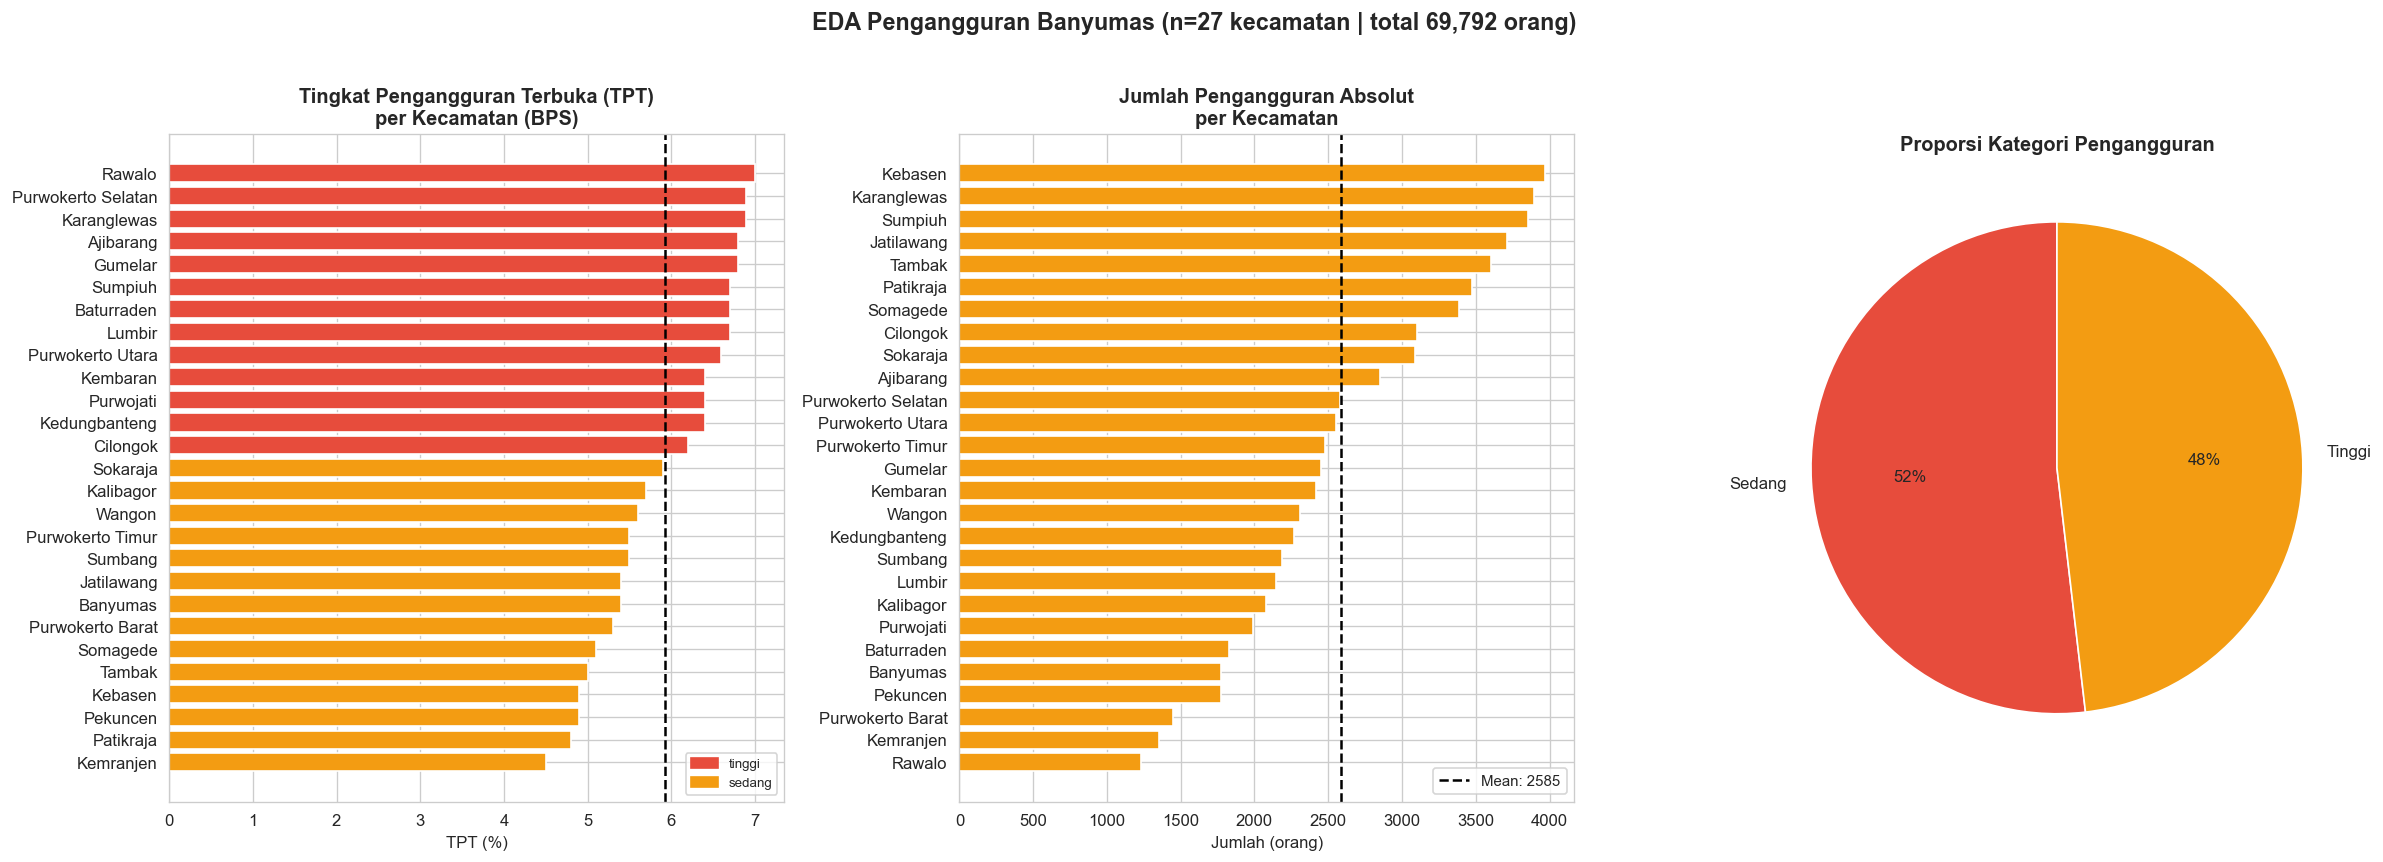

count    27.00
mean      5.93
std       0.78
min       4.50
25%       5.35
50%       5.90
75%       6.70
max       7.00
Name: tingkat_pengangguran, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
color_tpt = {'Tingkat pengangguran tinggi':'#e74c3c','Tingkat pengangguran sedang':'#f39c12'}

# Bar horizontal TPT
tpt_sorted = pengangguran.sort_values('tingkat_pengangguran', ascending=True)
bar_colors_tpt = [color_tpt.get(i,'#7f8c8d') for i in tpt_sorted['interpretasi']]
axes[0].barh(tpt_sorted['kecamatan'], tpt_sorted['tingkat_pengangguran'],
            color=bar_colors_tpt, edgecolor='white')
axes[0].axvline(tpt_sorted['tingkat_pengangguran'].mean(), color='black', linestyle='--',
               label=f'Mean: {tpt_sorted["tingkat_pengangguran"].mean():.1f}%')
axes[0].set_title('Tingkat Pengangguran Terbuka (TPT)\nper Kecamatan (BPS)', fontweight='bold')
axes[0].set_xlabel('TPT (%)')
axes[0].legend(fontsize=9)
patches_tpt = [mpatches.Patch(color=v, label=k.replace('Tingkat pengangguran ',''))
               for k, v in color_tpt.items()]
axes[0].legend(handles=patches_tpt, fontsize=8)

# Bar jumlah pengangguran
tpt_jml = pengangguran.sort_values('jumlah_pengangguran', ascending=True)
axes[1].barh(tpt_jml['kecamatan'], tpt_jml['jumlah_pengangguran'],
            color='#f39c12', edgecolor='white')
axes[1].axvline(tpt_jml['jumlah_pengangguran'].mean(), color='black', linestyle='--',
               label=f'Mean: {tpt_jml["jumlah_pengangguran"].mean():.0f}')
axes[1].set_title('Jumlah Pengangguran Absolut\nper Kecamatan', fontweight='bold')
axes[1].set_xlabel('Jumlah (orang)')
axes[1].legend(fontsize=9)

# Pie interpretasi
interp_tpt_vc = pengangguran['interpretasi'].value_counts()
labels_pie = [l.replace('Tingkat pengangguran ','').capitalize() for l in interp_tpt_vc.index]
axes[2].pie(interp_tpt_vc.values, labels=labels_pie, autopct='%1.0f%%',
           colors=['#e74c3c','#f39c12'], startangle=90)
axes[2].set_title('Proporsi Kategori Pengangguran', fontweight='bold')

plt.suptitle(f'EDA Pengangguran Banyumas (n={len(pengangguran)} kecamatan | '
             f'total {pengangguran["jumlah_pengangguran"].sum():,} orang)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_pengangguran.png', bbox_inches='tight')
plt.show()
print(pengangguran['tingkat_pengangguran'].describe().round(2))

---
## 5. EDA Gabungan Antar Variabel
### 5.1 Peta Semua Variabel

In [35]:
print(kepadatan.crs)
print(kepadatan.total_bounds)
print(gdf_koperasi.total_bounds)

EPSG:4326
[108.87234516  -7.67104874 109.45764605  -7.25759961]
[108.051142   -7.6308009 109.42207     7.612223 ]


In [36]:
# Temukan baris yang koordinatnya janggal
print(gdf_koperasi[gdf_koperasi['lat'] > 0][['Nama Koperasi', 'Kecamatan', 'Desa', 'Koordinat', 'lat', 'lon']])

                                        Nama Koperasi      Kecamatan  \
13  KOPERASI DESA MERAH PUTIH KARANGSALAM KIDUL KE...  Kedungbanteng   

                 Desa             Koordinat       lat         lon  
13  Karangsalam Kidul  7.612223, 109.325529  7.612223  109.325529  


In [37]:
# Drop atau fix baris dengan koordinat invalid
gdf_koperasi = gdf_koperasi[gdf_koperasi['lat'] < 0].copy()
gdf_koperasi = gdf_koperasi.set_geometry(
    gpd.points_from_xy(gdf_koperasi['lon'], gdf_koperasi['lat'])
)
gdf_koperasi.crs = 'EPSG:4326'

# Verifikasi
print(gdf_koperasi.total_bounds)
print(f"Sisa koperasi: {len(gdf_koperasi)}")

[108.051142    -7.6308009  109.42207     -7.29302786]
Sisa koperasi: 116


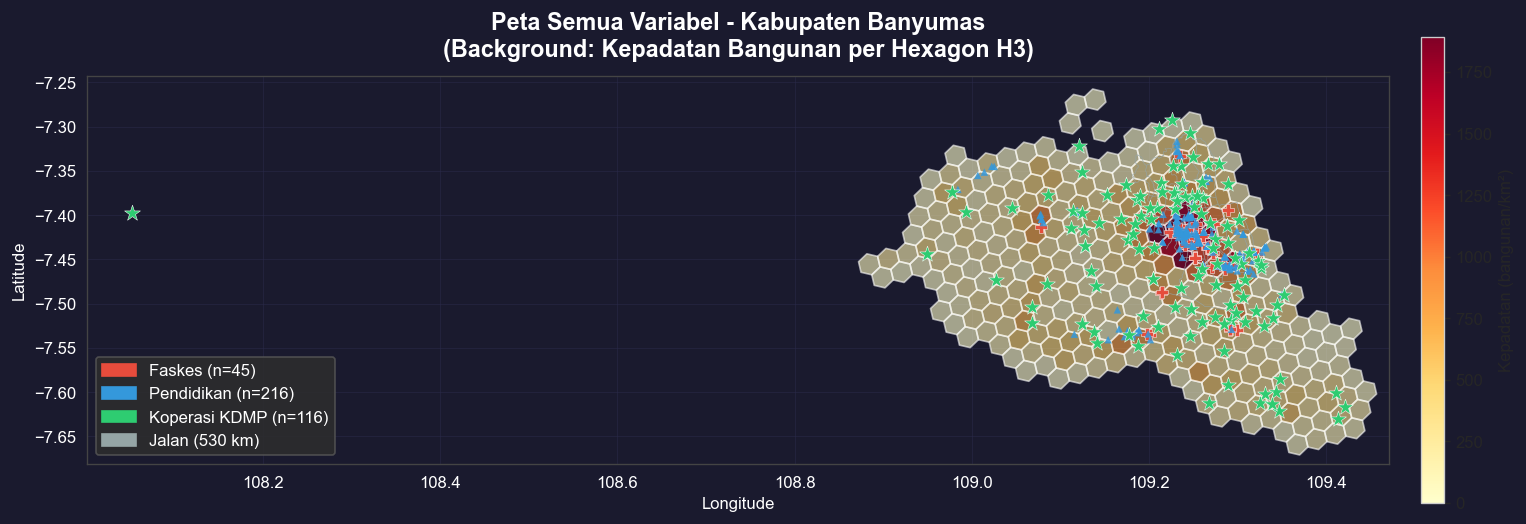

In [38]:
# Definisikan faskes_pt dan pendidikan_pt dulu (centroid jika polygon)
faskes_pt = faskes.copy().to_crs('EPSG:4326')
if faskes_pt.geometry.geom_type.isin(['Polygon','MultiPolygon']).any():
    faskes_pt['geometry'] = faskes_pt.geometry.centroid

pendidikan_pt = pendidikan.copy().to_crs('EPSG:4326')
if pendidikan_pt.geometry.geom_type.isin(['Polygon','MultiPolygon']).any():
    pendidikan_pt['geometry'] = pendidikan_pt.geometry.centroid

# Samakan CRS semua layer (tanpa inplace)
kepadatan_plot = kepadatan.to_crs('EPSG:4326')
jalan_plot     = jalan.to_crs('EPSG:4326')

# Ambil bounding box dari koperasi sebagai acuan wilayah Banyumas
minx = gdf_koperasi.geometry.x.min() - 0.05
maxx = gdf_koperasi.geometry.x.max() + 0.05
miny = gdf_koperasi.geometry.y.min() - 0.05
maxy = gdf_koperasi.geometry.y.max() + 0.05

fig, ax = plt.subplots(figsize=(14, 10), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Layer 1: Hexagon kepadatan — clip ke bounding box dulu
kepadatan_clipped = kepadatan_plot.cx[minx:maxx, miny:maxy]
kepadatan_clipped.plot(ax=ax, column='density', cmap='YlOrRd', alpha=0.6,
                       legend=True,
                       legend_kwds={'label':'Kepadatan (bangunan/km²)',
                                    'shrink':0.4, 'pad':0.02})

# Layer 2: Jalan — clip juga
jalan_clipped = jalan_plot.cx[minx:maxx, miny:maxy]
jalan_clipped.plot(ax=ax, color='#95a5a6', linewidth=0.4, alpha=0.5)

# Layer 3: Faskes & Pendidikan
faskes_pt.plot(ax=ax, color='#e74c3c', markersize=60, alpha=0.95, zorder=5, marker='P',
               edgecolors='white', linewidths=0.3)
pendidikan_pt.plot(ax=ax, color='#3498db', markersize=20, alpha=0.85, zorder=5, marker='^',
                   edgecolors='none')

# Layer 4: Koperasi
gdf_koperasi.plot(ax=ax, color='#2ecc71', markersize=100, marker='*',
                  alpha=1.0, zorder=10, edgecolors='white', linewidths=0.3)

# Kunci extent ke wilayah Banyumas
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_aspect('equal')

legend_el = [
    mpatches.Patch(color='#e74c3c', label=f'Faskes (n={len(faskes_pt)})'),
    mpatches.Patch(color='#3498db', label=f'Pendidikan (n={len(pendidikan_pt)})'),
    mpatches.Patch(color='#2ecc71', label=f'Koperasi KDMP (n={len(gdf_koperasi)})'),
    mpatches.Patch(color='#95a5a6', label=f'Jalan ({jalan["length"].sum()/1000:.0f} km)'),
]
leg = ax.legend(handles=legend_el, loc='lower left', fontsize=10,
                facecolor='#2d2d2d', edgecolor='#555', labelcolor='white', framealpha=0.85)

ax.set_title('Peta Semua Variabel - Kabupaten Banyumas\n(Background: Kepadatan Bangunan per Hexagon H3)',
             fontsize=14, fontweight='bold', color='white', pad=12)
ax.tick_params(colors='white')
ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.grid(True, color='#2a2a4a', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig('peta_semua_variabel.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

### 5.2 Korelasi Kemiskinan vs Pengangguran

Kecamatan match: 23


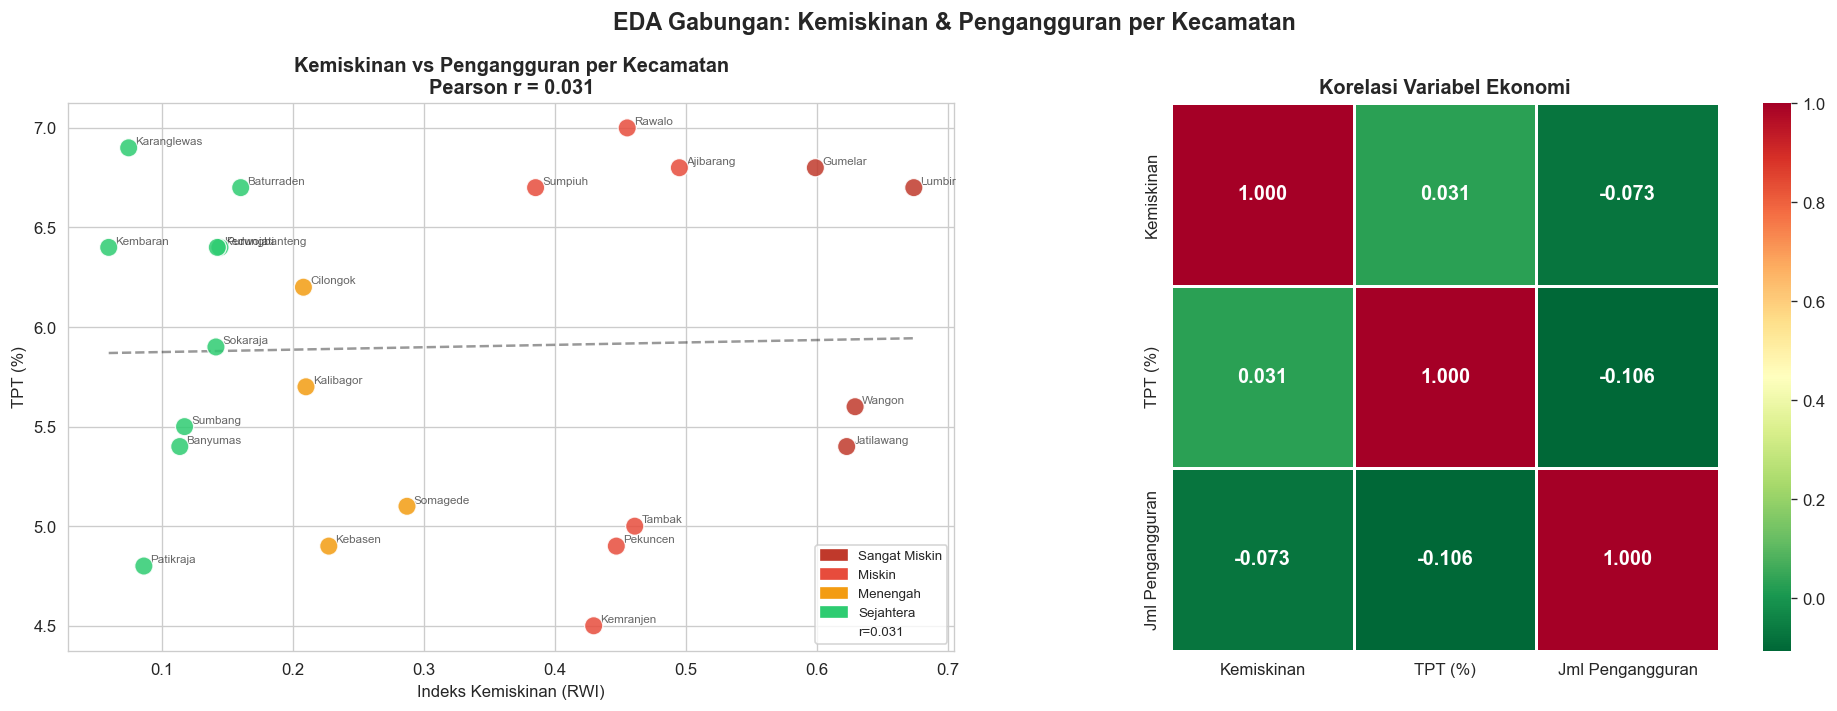

In [20]:
df_ekonomi = pd.merge(
    kemiskinan[['kecamatan','indeks_kemiskinan_mean','interpretasi']],
    pengangguran[['kecamatan','tingkat_pengangguran','jumlah_pengangguran',
                  'interpretasi']].rename(columns={'interpretasi':'interp_tpt'}),
    on='kecamatan', how='inner'
)
print(f'Kecamatan match: {len(df_ekonomi)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter kemiskinan vs pengangguran
dot_cols = [color_interp.get(i,'#7f8c8d') for i in df_ekonomi['interpretasi']]
axes[0].scatter(df_ekonomi['indeks_kemiskinan_mean'], df_ekonomi['tingkat_pengangguran'],
               c=dot_cols, s=120, alpha=0.85, edgecolors='white', linewidth=0.8, zorder=5)
for _, row in df_ekonomi.iterrows():
    axes[0].annotate(row['kecamatan'],
                    (row['indeks_kemiskinan_mean'], row['tingkat_pengangguran']),
                    fontsize=7, alpha=0.7, xytext=(4,2), textcoords='offset points')
z = np.polyfit(df_ekonomi['indeks_kemiskinan_mean'], df_ekonomi['tingkat_pengangguran'], 1)
x_line = np.linspace(df_ekonomi['indeks_kemiskinan_mean'].min(),
                     df_ekonomi['indeks_kemiskinan_mean'].max(), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), 'k--', alpha=0.4, linewidth=1.5, label='Trend')
corr_val = df_ekonomi['indeks_kemiskinan_mean'].corr(df_ekonomi['tingkat_pengangguran'])
axes[0].set_title(f'Kemiskinan vs Pengangguran per Kecamatan\nPearson r = {corr_val:.3f}',
                 fontweight='bold')
axes[0].set_xlabel('Indeks Kemiskinan (RWI)')
axes[0].set_ylabel('TPT (%)')
axes[0].legend(handles=patches_m + [mpatches.Patch(color='none', label=f'r={corr_val:.3f}')],
              fontsize=8)

# Heatmap korelasi
cols_corr = ['indeks_kemiskinan_mean','tingkat_pengangguran','jumlah_pengangguran']
rename_c = {'indeks_kemiskinan_mean':'Kemiskinan','tingkat_pengangguran':'TPT (%)','jumlah_pengangguran':'Jml Pengangguran'}
sns.heatmap(df_ekonomi[cols_corr].rename(columns=rename_c).corr(),
           annot=True, fmt='.3f', cmap='RdYlGn_r', ax=axes[1],
           square=True, linewidths=1.5, annot_kws={'size':12,'weight':'bold'})
axes[1].set_title('Korelasi Variabel Ekonomi', fontweight='bold')

plt.suptitle('EDA Gabungan: Kemiskinan & Pengangguran per Kecamatan',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_korelasi_ekonomi.png', bbox_inches='tight')
plt.show()

### 5.3 Jarak Koperasi ke Fasilitas Terdekat (Euclidean Distance)

In [21]:
kop_utm   = gdf_koperasi.to_crs(epsg=32749)
faskes_utm= faskes_pt.to_crs(epsg=32749)
pend_utm  = pendidikan_pt.to_crs(epsg=32749)
jalan_utm = jalan.to_crs(epsg=32749)
pemuk_utm = pemukiman.to_crs(epsg=32749)

def nearest_dist(gdf_from, gdf_to):
    coords_to = np.array([
        (g.centroid.x, g.centroid.y) if g.geom_type != 'Point' else (g.x, g.y)
        for g in gdf_to.geometry
    ])
    coords_from = np.array([(g.x, g.y) for g in gdf_from.geometry])
    dist, _ = cKDTree(coords_to).query(coords_from, k=1)
    return dist

gdf_koperasi['jarak_faskes_m']    = nearest_dist(kop_utm, faskes_utm)
gdf_koperasi['jarak_pendidikan_m']= nearest_dist(kop_utm, pend_utm)
gdf_koperasi['jarak_jalan_m']     = nearest_dist(kop_utm, jalan_utm)
gdf_koperasi['jarak_pemukiman_m'] = nearest_dist(kop_utm, pemuk_utm)

print('Statistik jarak koperasi ke fasilitas (meter):')
print(gdf_koperasi[['jarak_faskes_m','jarak_pendidikan_m',
                     'jarak_jalan_m','jarak_pemukiman_m']].describe().round(1))

Statistik jarak koperasi ke fasilitas (meter):
       jarak_faskes_m  jarak_pendidikan_m  jarak_jalan_m  jarak_pemukiman_m
count           117.0               117.0          117.0              117.0
mean          19812.9             18177.1        20515.5            14967.0
std          152643.1            152567.4       152493.9           152335.8
min             542.0                15.4           28.7                1.6
25%            2230.0              1166.6          902.2               11.9
50%            4045.9              2005.2         2762.9               34.7
75%            6414.1              4250.4         8147.3              123.0
max         1652812.9           1650958.6      1650231.9          1646041.0


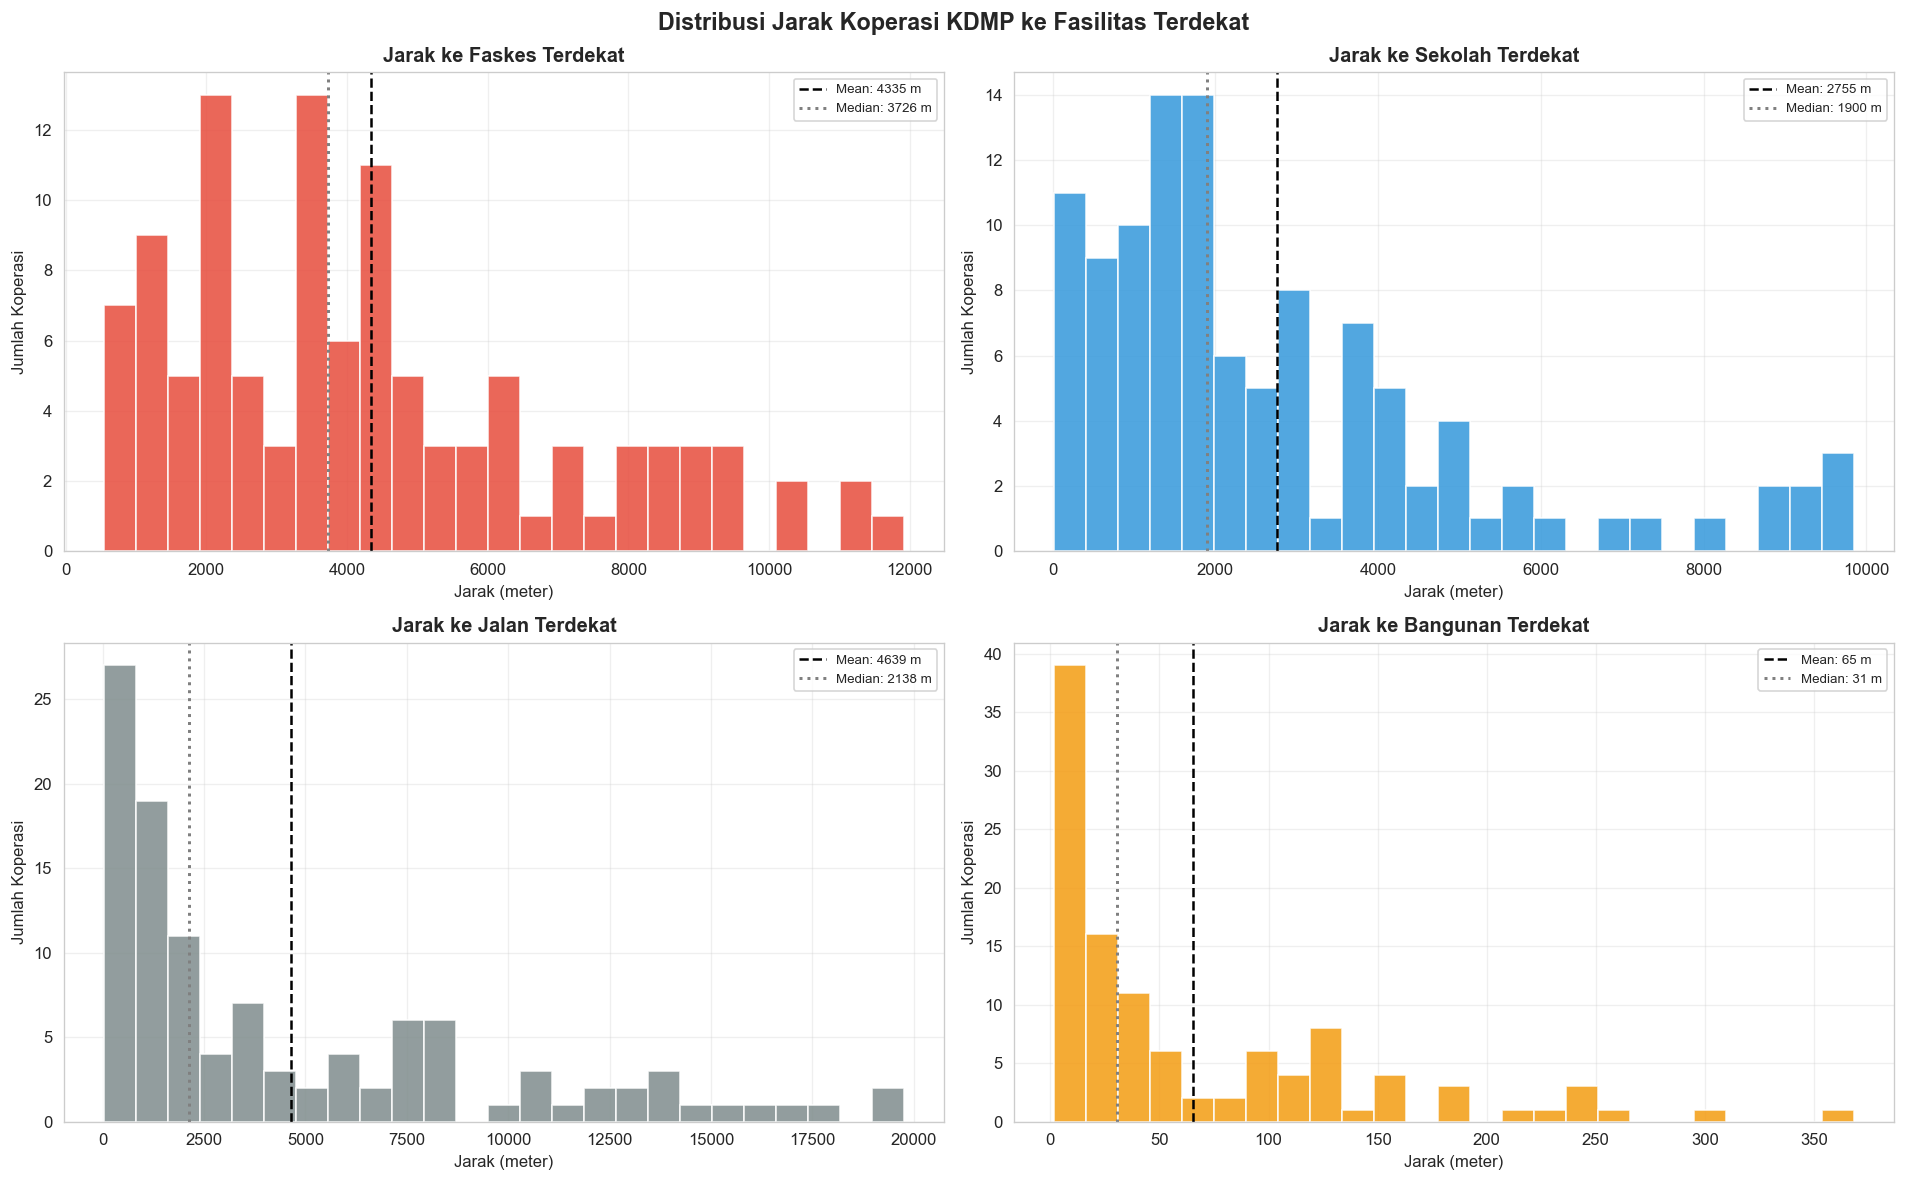

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

cols_jarak = [
    ('jarak_faskes_m', 'Jarak ke Faskes Terdekat', '#e74c3c'),
    ('jarak_pendidikan_m', 'Jarak ke Sekolah Terdekat', '#3498db'),
    ('jarak_jalan_m', 'Jarak ke Jalan Terdekat', '#7f8c8d'),
    ('jarak_pemukiman_m', 'Jarak ke Bangunan Terdekat', '#f39c12')
]

for i, (col, title, color) in enumerate(cols_jarak):
    data = gdf_koperasi[col].dropna()
    
    # biar visual lebih kebaca, fokus ke mayoritas data
    batas = data.quantile(0.95)
    data_plot = data[data <= batas]
    
    axes[i].hist(
        data_plot,
        bins=25,
        color=color,
        edgecolor='white',
        alpha=0.85
    )
    
    axes[i].axvline(
        data_plot.mean(),
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f'Mean: {data_plot.mean():.0f} m'
    )
    
    axes[i].axvline(
        data_plot.median(),
        color='gray',
        linestyle=':',
        linewidth=1.8,
        label=f'Median: {data_plot.median():.0f} m'
    )
    
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Jarak (meter)')
    axes[i].set_ylabel('Jumlah Koperasi')
    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=8)

plt.suptitle(
    'Distribusi Jarak Koperasi KDMP ke Fasilitas Terdekat',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('eda_jarak_koperasi.png', bbox_inches='tight', dpi=300)
plt.show()

### 5.4 Jumlah Fasilitas dalam Buffer 500m & 1km

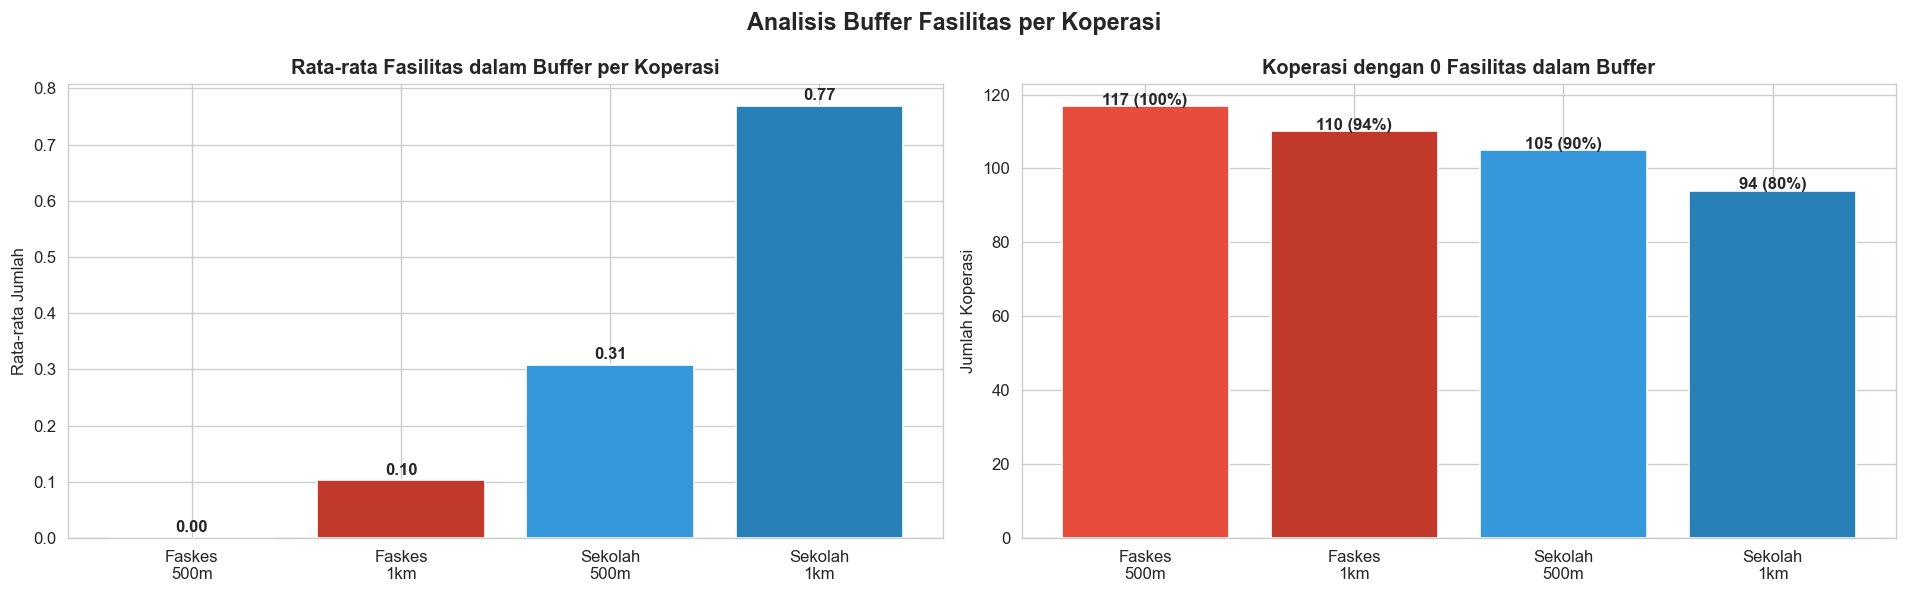


Koperasi dengan 0 faskes dalam radius 1km:
                                                                              Nama Koperasi      Kecamatan               Desa
0                     KOPERASI DESA MERAH PUTIH LEDUG KECAMATAN KEMBARAN KABUPATEN BANYUMAS       Kembaran              Ledug
1                 KOPERASI DESA MERAH PUTIH JIPANG KECAMATAN KARANGLEWAS KABUPATEN BANYUMAS    Karanglewas             Jipang
2                    KOPERASI DESA MERAH PUTIH SUSUKAN KECAMATAN SUMBANG KABUPATEN BANYUMAS        Sumbang            Susukan
3                   KOPERASI DESA MERAH PUTIH SROWOT KECAMATAN KALIBAGOR KABUPATEN BANYUMAS      Kalibagor             Srowot
4              KOPERASI DESA MERAH PUTIH GENTAWANGI KECAMATAN JATILAWANG KABUPATEN BANYUMAS     Jatilawang         Gentawangi
5                KOPERASI DESA MERAH PUTIH KETENGER KECAMATAN BATURRADEN KABUPATEN BANYUMAS     Baturraden           Ketenger
7                    KOPERASI DESA MERAH PUTIH KUNTILI KECAMATAN SUMPIUH K

In [23]:
def count_in_buffer(gdf_center, gdf_target, radius_m):
    center_utm = gdf_center.to_crs(epsg=32749).copy()
    target_utm = gdf_target.to_crs(epsg=32749).copy()
    if target_utm.geometry.type.isin(['Polygon','MultiPolygon']).any():
        target_utm = target_utm.copy()
        target_utm['geometry'] = target_utm.geometry.centroid
    buf = center_utm.copy()
    buf['geometry'] = buf.geometry.buffer(radius_m)
    joined = gpd.sjoin(target_utm, buf[['geometry']], how='inner', predicate='within')
    counts = joined.groupby('index_right').size()
    return center_utm.index.map(counts).fillna(0).astype(int)

gdf_koperasi['faskes_500m']    = count_in_buffer(gdf_koperasi, faskes_pt, 500)
gdf_koperasi['faskes_1km']     = count_in_buffer(gdf_koperasi, faskes_pt, 1000)
gdf_koperasi['pendidikan_500m']= count_in_buffer(gdf_koperasi, pendidikan_pt, 500)
gdf_koperasi['pendidikan_1km'] = count_in_buffer(gdf_koperasi, pendidikan_pt, 1000)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels_buf = ['Faskes\n500m','Faskes\n1km','Sekolah\n500m','Sekolah\n1km']
means_buf = [gdf_koperasi['faskes_500m'].mean(), gdf_koperasi['faskes_1km'].mean(),
             gdf_koperasi['pendidikan_500m'].mean(), gdf_koperasi['pendidikan_1km'].mean()]
bars = axes[0].bar(labels_buf, means_buf, color=['#e74c3c','#c0392b','#3498db','#2980b9'], edgecolor='white')
for bar, val in zip(bars, means_buf):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontweight='bold')
axes[0].set_title('Rata-rata Fasilitas dalam Buffer per Koperasi', fontweight='bold')
axes[0].set_ylabel('Rata-rata Jumlah')

zero_stats = {
    'Faskes\n500m': (gdf_koperasi['faskes_500m']==0).sum(),
    'Faskes\n1km':  (gdf_koperasi['faskes_1km']==0).sum(),
    'Sekolah\n500m':(gdf_koperasi['pendidikan_500m']==0).sum(),
    'Sekolah\n1km': (gdf_koperasi['pendidikan_1km']==0).sum(),
}
bars2 = axes[1].bar(zero_stats.keys(), zero_stats.values(),
                   color=['#e74c3c','#c0392b','#3498db','#2980b9'], edgecolor='white')
for bar, v in zip(bars2, zero_stats.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v} ({v/len(gdf_koperasi)*100:.0f}%)', ha='center', fontweight='bold')
axes[1].set_title('Koperasi dengan 0 Fasilitas dalam Buffer', fontweight='bold')
axes[1].set_ylabel('Jumlah Koperasi')

plt.suptitle('Analisis Buffer Fasilitas per Koperasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_buffer_fasilitas.png', bbox_inches='tight')
plt.show()

print('\nKoperasi dengan 0 faskes dalam radius 1km:')
print(gdf_koperasi[gdf_koperasi['faskes_1km']==0][['Nama Koperasi','Kecamatan','Desa']].to_string())

### 5.5 Koperasi vs Kepadatan Penduduk (Spatial Join ke Hexagon)

Koperasi per kategori kepadatan hexagon:
kategori_density
Tinggi    82
Sedang    27
Rendah     6
Name: count, dtype: int64
Koperasi di luar coverage hexagon: 2


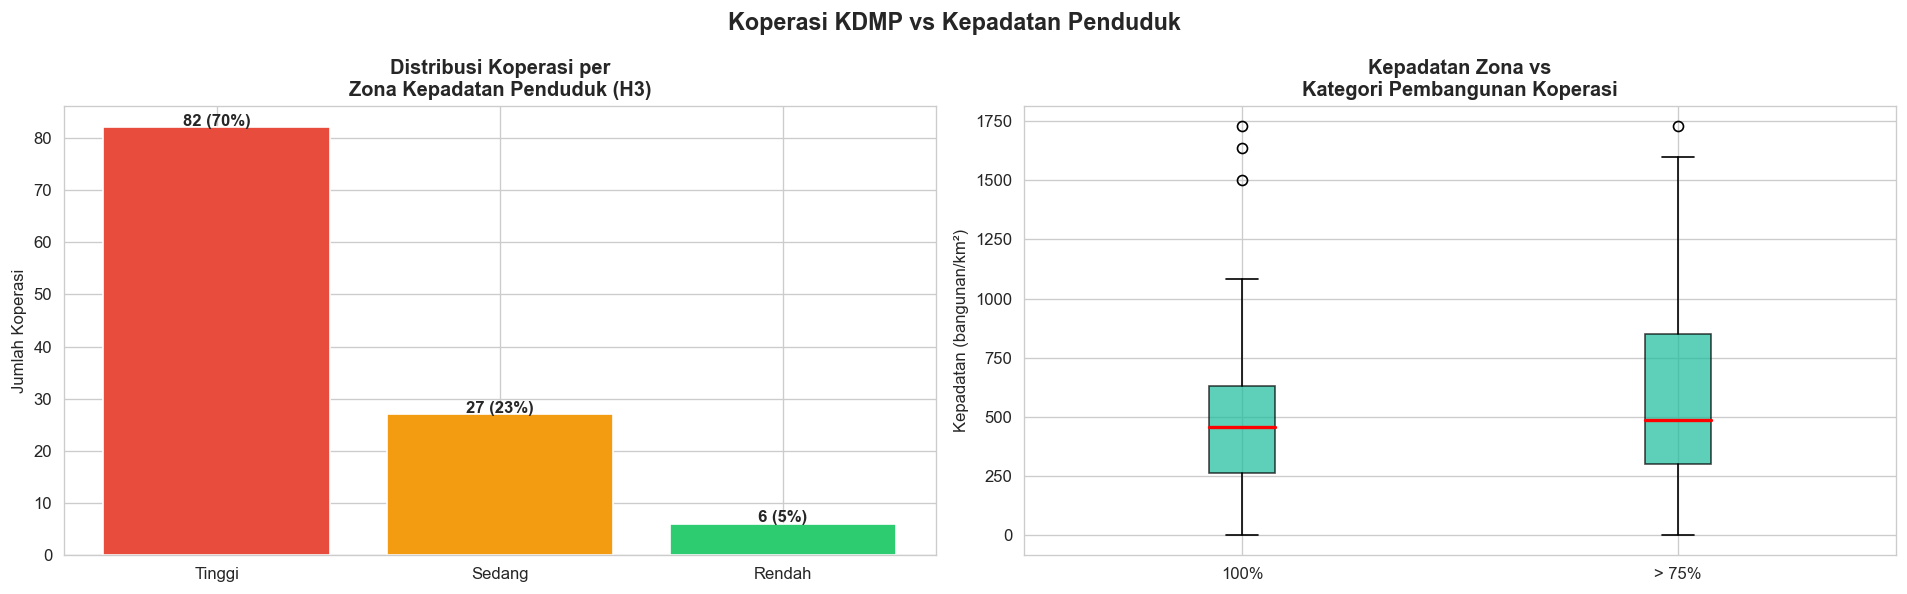

In [24]:
kop_hex = gpd.sjoin(
    gdf_koperasi[['Nama Koperasi','Kecamatan','Desa','geometry',
                  'Progres Pembangunan (%)','Kategori Pembangunan']],
    kepadatan[['geometry','building_count','density','kategori_density']],
    how='left', predicate='within'
)

print('Koperasi per kategori kepadatan hexagon:')
print(kop_hex['kategori_density'].value_counts())
print(f'Koperasi di luar coverage hexagon: {kop_hex["kategori_density"].isna().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

kat_kop = kop_hex['kategori_density'].value_counts()
bars = axes[0].bar([k for k in ['Tinggi','Sedang','Rendah'] if k in kat_kop],
                  [kat_kop.get(k,0) for k in ['Tinggi','Sedang','Rendah'] if k in kat_kop],
                  color=[color_kat[k] for k in ['Tinggi','Sedang','Rendah'] if k in kat_kop],
                  edgecolor='white')
for bar, k in zip(bars, [k for k in ['Tinggi','Sedang','Rendah'] if k in kat_kop]):
    v = kat_kop.get(k,0)
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v} ({v/len(kop_hex)*100:.0f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribusi Koperasi per\nZona Kepadatan Penduduk (H3)', fontweight='bold')
axes[0].set_ylabel('Jumlah Koperasi')

kop_hex_c = kop_hex.dropna(subset=['density'])
kat_labels = kop_hex_c['Kategori Pembangunan'].unique()
data_bx = [kop_hex_c[kop_hex_c['Kategori Pembangunan']==k]['density'].values for k in kat_labels]
axes[1].boxplot(data_bx, labels=kat_labels, patch_artist=True,
               boxprops=dict(facecolor='#1abc9c', alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Kepadatan Zona vs\nKategori Pembangunan Koperasi', fontweight='bold')
axes[1].set_ylabel('Kepadatan (bangunan/km²)')

plt.suptitle('Koperasi KDMP vs Kepadatan Penduduk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_koperasi_kepadatan.png', bbox_inches='tight')
plt.show()

### 5.6 Skor Kerentanan Awal per Koperasi

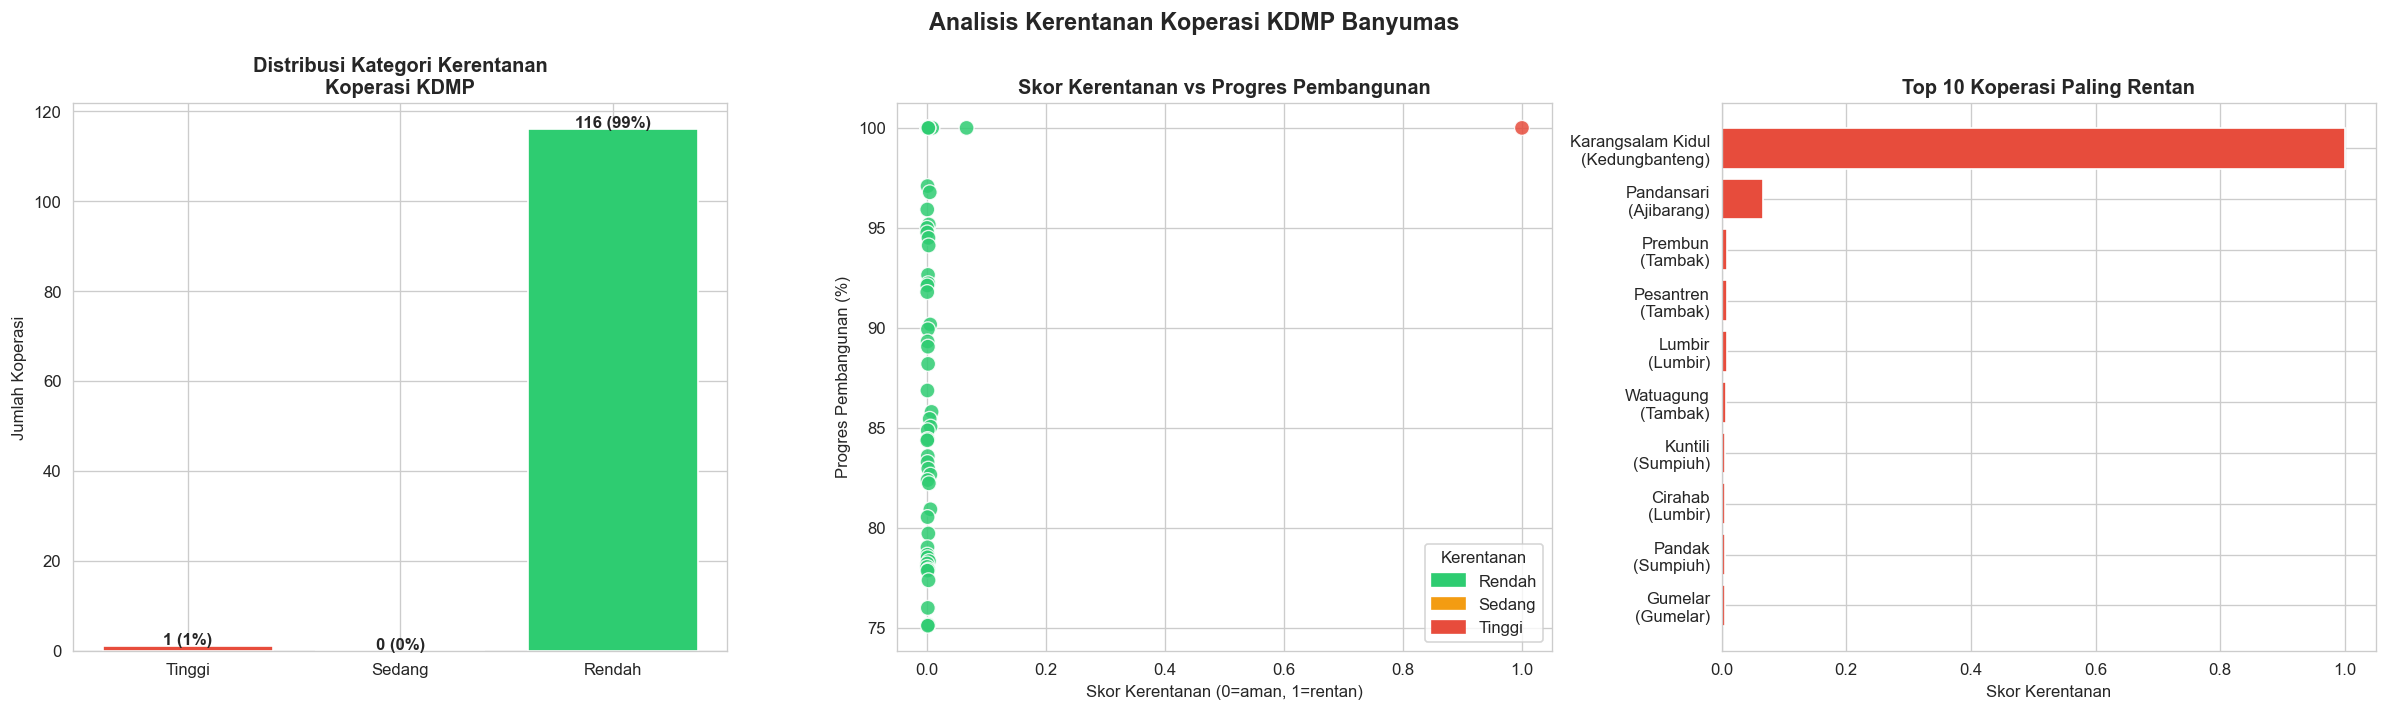


Top 10 koperasi PALING RENTAN:
                                                                              Nama Koperasi      Kecamatan               Desa  skor_rentan  jarak_faskes_m  jarak_jalan_m  Progres Pembangunan (%)
13   KOPERASI DESA MERAH PUTIH KARANGSALAM KIDUL KECAMATAN KEDUNGBANTENG KABUPATEN BANYUMAS  Kedungbanteng  Karangsalam Kidul          1.0       1652812.9      1650231.9                    100.0
30              KOPERASI DESA MERAH PUTIH PANDANSARI KECAMATAN AJIBARANG KABUPATEN BANYUMAS      Ajibarang         Pandansari          0.1        113505.8       125188.2                    100.0
9                     KOPERASI DESA MERAH PUTIH PREMBUN KECAMATAN TAMBAK KABUPATEN BANYUMAS         Tambak            Prembun          0.0         16907.8        21847.6                    100.0
66                  KOPERASI DESA MERAH PUTIH PESANTREN KECAMATAN TAMBAK KABUPATEN BANYUMAS         Tambak          Pesantren          0.0         16613.6        21209.8                   

In [25]:
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

# Semakin jauh dari fasilitas = semakin rentan
gdf_koperasi['skor_rentan'] = (
    normalize(gdf_koperasi['jarak_faskes_m'])     * 0.30 +
    normalize(gdf_koperasi['jarak_pendidikan_m']) * 0.25 +
    normalize(gdf_koperasi['jarak_jalan_m'])      * 0.25 +
    normalize(gdf_koperasi['jarak_pemukiman_m'])  * 0.20
)

gdf_koperasi['kategori_rentan'] = pd.cut(
    gdf_koperasi['skor_rentan'],
    bins=[0, 0.33, 0.66, 1.01],
    labels=['Rendah','Sedang','Tinggi'],
    include_lowest=True
)

colors_rentan = {'Rendah':'#2ecc71','Sedang':'#f39c12','Tinggi':'#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribusi kategori
rentan_vc = gdf_koperasi['kategori_rentan'].value_counts()
order_r = ['Tinggi','Sedang','Rendah']
bars = axes[0].bar([k for k in order_r if k in rentan_vc],
                  [rentan_vc.get(k,0) for k in order_r if k in rentan_vc],
                  color=[colors_rentan[k] for k in order_r if k in rentan_vc], edgecolor='white')
for bar, k in zip(bars, [k for k in order_r if k in rentan_vc]):
    v = rentan_vc.get(k,0)
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v} ({v/len(gdf_koperasi)*100:.0f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribusi Kategori Kerentanan\nKoperasi KDMP', fontweight='bold')
axes[0].set_ylabel('Jumlah Koperasi')

# Scatter skor vs progres
dot_col = gdf_koperasi['kategori_rentan'].map(colors_rentan)
axes[1].scatter(gdf_koperasi['skor_rentan'], gdf_koperasi['Progres Pembangunan (%)'],
               c=dot_col, s=80, alpha=0.85, edgecolors='white', linewidth=0.8)
axes[1].set_xlabel('Skor Kerentanan (0=aman, 1=rentan)')
axes[1].set_ylabel('Progres Pembangunan (%)')
axes[1].set_title('Skor Kerentanan vs Progres Pembangunan', fontweight='bold')
axes[1].legend(handles=[mpatches.Patch(color=v, label=k) for k, v in colors_rentan.items()],
              title='Kerentanan')

# Top 10 paling rentan
top10 = gdf_koperasi.nlargest(10, 'skor_rentan')
label_top = top10['Desa'] + '\n(' + top10['Kecamatan'] + ')'
axes[2].barh(label_top[::-1].values, top10['skor_rentan'][::-1].values,
            color='#e74c3c', edgecolor='white')
axes[2].set_title('Top 10 Koperasi Paling Rentan', fontweight='bold')
axes[2].set_xlabel('Skor Kerentanan')

plt.suptitle('Analisis Kerentanan Koperasi KDMP Banyumas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_skor_kerentanan.png', bbox_inches='tight')
plt.show()

print('\nTop 10 koperasi PALING RENTAN:')
cols_show = ['Nama Koperasi','Kecamatan','Desa','skor_rentan',
             'jarak_faskes_m','jarak_jalan_m','Progres Pembangunan (%)']
print(gdf_koperasi.nlargest(10,'skor_rentan')[cols_show].round(1).to_string())

### 5.7 Peta Interaktif (Folium)

In [30]:
m = folium.Map(
    location=[gdf_koperasi['lat'].mean(), gdf_koperasi['lon'].mean()],
    zoom_start=11, tiles='CartoDB dark_matter'
)

# Layer 1: Heatmap bangunan
centroids = pemukiman.copy()
centroids['geometry'] = pemukiman.geometry.centroid
HeatMap([[g.y, g.x] for g in centroids.geometry],
        radius=4, blur=3, min_opacity=0.2, name='Kepadatan Bangunan').add_to(m)

# Layer 2: Hexagon kepadatan
hex_fg = folium.FeatureGroup(name='Hexagon Kepadatan H3', show=False)
cmap_hex = {'Rendah':'#2ecc71','Sedang':'#f39c12','Tinggi':'#e74c3c'}
for _, row in kepadatan.iterrows():
    c = cmap_hex.get(row['kategori_density'],'#7f8c8d')
    folium.GeoJson(row['geometry'].__geo_interface__,
                  style_function=lambda x, col=c: {'fillColor':col,'color':'none','fillOpacity':0.5},
                  tooltip=f"{row['kategori_density']} | {row['density']} bdg/km²").add_to(hex_fg)
hex_fg.add_to(m)

# Layer 3: Faskes
fg_faskes = folium.FeatureGroup(name='Fasilitas Kesehatan')
for _, row in faskes_pt.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x], radius=7,
        color='#e74c3c', fill=True, fill_opacity=0.9,
        popup=f"<b>{row.get('name','Faskes')}</b><br>Jenis: {row.get('jenis','')}"
    ).add_to(fg_faskes)
fg_faskes.add_to(m)

# Layer 4: Pendidikan
fg_pend = folium.FeatureGroup(name='Fasilitas Pendidikan')
for _, row in pendidikan_pt.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x], radius=5,
        color='#3498db', fill=True, fill_opacity=0.9,
        popup=f"<b>{row.get('name','Sekolah')}</b><br>Jenis: {row.get('amenity','')}"
    ).add_to(fg_pend)
fg_pend.add_to(m)

# Layer 5: Koperasi dengan warna kerentanan
fg_kop = folium.FeatureGroup(name='Koperasi KDMP (warna=kerentanan)')
icon_map = {'Rendah':'green','Sedang':'orange','Tinggi':'red'}
for _, row in gdf_koperasi.iterrows():
    popup_html = f"""
    <b>{row['Nama Koperasi']}</b><br>
    Kecamatan: {row['Kecamatan']} | Desa: {row['Desa']}<br>
    Progres: {row['Progres Pembangunan (%)']:.1f}%<br><hr>
    <b>Kerentanan: {row['skor_rentan']:.3f} ({row['kategori_rentan']})</b><br>
    Jarak faskes: {row['jarak_faskes_m']:.0f} m<br>
    Jarak sekolah: {row['jarak_pendidikan_m']:.0f} m<br>
    Jarak jalan: {row['jarak_jalan_m']:.0f} m<br>
    Faskes dalam 1km: {row['faskes_1km']}<br>
    Sekolah dalam 1km: {row['pendidikan_1km']}
    """
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=f"{row['Desa']} ({row['kategori_rentan']})",
        icon=folium.Icon(color=icon_map.get(str(row['kategori_rentan']),'gray'),
                        icon='home', prefix='fa')
    ).add_to(fg_kop)
fg_kop.add_to(m)

folium.LayerControl().add_to(m)
m.save('peta_interaktif_goal2.html')
print('Peta interaktif disimpan: peta_interaktif_goal2.html')

Peta interaktif disimpan: peta_interaktif_goal2.html


## 6. Export Hasil & Ringkasan

In [28]:
cols_export = [
    'Nama Koperasi','Kecamatan','Desa','lat','lon',
    'Progres Pembangunan (%)','Kategori Pembangunan',
    'jarak_faskes_m','jarak_pendidikan_m','jarak_jalan_m','jarak_pemukiman_m',
    'faskes_500m','faskes_1km','pendidikan_500m','pendidikan_1km',
    'skor_rentan','kategori_rentan'
]
gdf_koperasi[cols_export].to_csv('hasil_eda_koperasi_goal2.csv', index=False)

print('=== RINGKASAN EDA GOAL 2 ===')
print(f'Total koperasi            : {len(gdf_koperasi)}')
print(f'Kecamatan terlibat        : {gdf_koperasi["Kecamatan"].nunique()}')
print(f'Progres rata-rata         : {gdf_koperasi["Progres Pembangunan (%)"].mean():.1f}%')
print(f'Jarak rata-rata ke faskes : {gdf_koperasi["jarak_faskes_m"].mean():.0f} m')
print(f'Jarak rata-rata ke sekolah: {gdf_koperasi["jarak_pendidikan_m"].mean():.0f} m')
print(f'Jarak rata-rata ke jalan  : {gdf_koperasi["jarak_jalan_m"].mean():.0f} m')
print(f'Koperasi tanpa faskes 1km : {(gdf_koperasi["faskes_1km"]==0).sum()}')
print()
print('Distribusi kerentanan:')
print(gdf_koperasi['kategori_rentan'].value_counts().to_string())
print()
print('Output files:')
files = [
    'hasil_eda_koperasi_goal2.csv','peta_interaktif_goal2.html',
    'peta_semua_variabel.png','eda_koperasi.png','eda_pemukiman.png',
    'eda_faskes.png','eda_pendidikan.png','eda_jalan.png','eda_kepadatan.png',
    'eda_kemiskinan.png','eda_pengangguran.png','eda_korelasi_ekonomi.png',
    'eda_jarak_koperasi.png','eda_buffer_fasilitas.png',
    'eda_koperasi_kepadatan.png','eda_skor_kerentanan.png'
]
for f in files:
    print(f'  {f}')

=== RINGKASAN EDA GOAL 2 ===
Total koperasi            : 117
Kecamatan terlibat        : 23
Progres rata-rata         : 94.4%
Jarak rata-rata ke faskes : 19813 m
Jarak rata-rata ke sekolah: 18177 m
Jarak rata-rata ke jalan  : 20515 m
Koperasi tanpa faskes 1km : 110

Distribusi kerentanan:
kategori_rentan
Rendah    116
Tinggi      1
Sedang      0

Output files:
  hasil_eda_koperasi_goal2.csv
  peta_interaktif_goal2.html
  peta_semua_variabel.png
  eda_koperasi.png
  eda_pemukiman.png
  eda_faskes.png
  eda_pendidikan.png
  eda_jalan.png
  eda_kepadatan.png
  eda_kemiskinan.png
  eda_pengangguran.png
  eda_korelasi_ekonomi.png
  eda_jarak_koperasi.png
  eda_buffer_fasilitas.png
  eda_koperasi_kepadatan.png
  eda_skor_kerentanan.png


In [31]:
# ============================================================
# RINGKASAN INFO SEMUA DATA
# ============================================================

datasets = {
    'Koperasi KDMP'        : gdf_koperasi,
    'Pemukiman'            : pemukiman,
    'Fasilitas Kesehatan'  : faskes,
    'Fasilitas Pendidikan' : pendidikan,
    'Jaringan Jalan'       : jalan,
    'Kepadatan Penduduk'   : kepadatan,
    'Kemiskinan'           : kemiskinan,
    'Pengangguran'         : pengangguran,
}

for nama, df in datasets.items():
    print('=' * 70)
    print(f'  {nama.upper()}')
    print('=' * 70)
    print(f'  Shape  : {df.shape}')
    print(f'  Kolom  : {df.columns.tolist()}')
    print(f'  CRS    : {df.crs}' if hasattr(df, "crs") else f'  Tipe   : DataFrame biasa')
    print()
    display(df.head(3))
    print()

  KOPERASI KDMP
  Shape  : (117, 23)
  Kolom  : ['kel', 'No', 'Nama Koperasi', 'Koordinat', 'Provinsi ', 'Kota', 'Kecamatan', 'Desa', 'Progres Pembangunan (%)', 'Kategori Pembangunan', 'lat', 'lon', 'geometry', 'jarak_faskes_m', 'jarak_pendidikan_m', 'jarak_jalan_m', 'jarak_pemukiman_m', 'faskes_500m', 'faskes_1km', 'pendidikan_500m', 'pendidikan_1km', 'skor_rentan', 'kategori_rentan']
  CRS    : EPSG:4326



,kel,No,Nama Koperasi,Koordinat,Provinsi,Kota,Kecamatan,Desa,Progres Pembangunan (%),Kategori Pembangunan,...,jarak_faskes_m,jarak_pendidikan_m,jarak_jalan_m,jarak_pemukiman_m,faskes_500m,faskes_1km,pendidikan_500m,pendidikan_1km,skor_rentan,kategori_rentan
0,1.0,1,KOPERASI DESA MERAH PUTIH LEDUG KECAMATAN KEMB...,"-7.42665842,109.2748667",JAWA TENGAH,KAB. BANYUMAS,Kembaran,Ledug,100.0,100%,...,1351.506725,682.191028,244.442637,93.760532,0,0,0,1,0.000292,Rendah
1,NaN,2,KOPERASI DESA MERAH PUTIH JIPANG KECAMATAN KAR...,"-7.401390, 109.191585",JAWA TENGAH,KAB. BANYUMAS,Karanglewas,Jipang,100.0,100%,...,4072.063079,1894.997913,965.855770,50.981458,0,0,0,0,0.001074,Rendah
2,NaN,3,KOPERASI DESA MERAH PUTIH SUSUKAN KECAMATAN SU...,"-7.364630982,109.2902862",JAWA TENGAH,KAB. BANYUMAS,Sumbang,Susukan,100.0,100%,...,3334.284346,2453.661260,1867.627175,22.139965,0,0,0,0,0.001157,Rendah



  PEMUKIMAN
  Shape  : (481032, 6)
  Kolom  : ['building', 'building:levels', 'addr:city', 'name', 'area_m2', 'geometry']
  CRS    : EPSG:4326



,building,building:levels,addr:city,name,area_m2,geometry
0,yes,None,None,None,7393.041545,"POLYGON ((109.24525 -7.41539, 109.24536 -7.415..."
1,yes,None,None,MIPA FST Unsoed,2853.176133,"POLYGON ((109.25371 -7.40716, 109.25391 -7.407..."
2,stadium,None,None,None,6456.577385,"POLYGON ((109.25045 -7.4151, 109.25051 -7.4151..."



  FASILITAS KESEHATAN
  Shape  : (45, 42)
  Kolom  : ['element', 'id', 'amenity', 'designation', 'emergency', 'name', 'addr:city', 'addr:district', 'addr:neighbourhood', 'addr:postcode', 'addr:province', 'addr:street', 'addr:subdistrict', 'healthcare', 'healthcare:speciality', 'website', 'addr:housenumber', 'mobile', 'operator', 'name:en', 'opening_hours', 'phone', 'operator:type', 'start_date', 'contact:facebook', 'email', 'building', 'source', 'contact:phone', 'health_amenity:type', 'insurance:health', 'operational_status', 'url', 'addr:full', 'building:levels', 'description', 'wikidata', 'wikipedia', 'beds', 'dispensing', 'geometry', 'jenis']
  CRS    : EPSG:4326



...

,hex_id,building_count,hex_area_km2,density,kategori_density,geometry
0,878d89822ffffff,322,5.016522,64,Rendah,"POLYGON ((108.89668 -7.45854, 108.8939 -7.4466..."
1,878d89826ffffff,86,5.014385,17,Rendah,"POLYGON ((108.91163 -7.47328, 108.90885 -7.461..."
2,878d89834ffffff,647,5.014914,129,Sedang,"POLYGON ((108.93979 -7.44633, 108.93702 -7.434..."



  KEMISKINAN
  Shape  : (23, 16)
  Kolom  : ['kecamatan', 'latitude', 'longitude', 'geometry', 'jumlah_tile', 'rwi_mean', 'rwi_median', 'rwi_min', 'rwi_max', 'indeks_kemiskinan_mean', 'rank_termiskin', 'kabupaten', 'provinsi', 'tahun_data', 'sumber', 'interpretasi']
  Tipe   : DataFrame biasa



,kecamatan,latitude,longitude,geometry,jumlah_tile,rwi_mean,rwi_median,rwi_min,rwi_max,indeks_kemiskinan_mean,rank_termiskin,kabupaten,provinsi,tahun_data,sumber,interpretasi
0,Lumbir,-7.48,108.865,POINT(108.865 -7.48),20,-141.159,-13.815,-19.546,-0.8920,0.674080,1,Banyumas,Jawa Tengah,2023,Meta RWI - HDX,Sangat Miskin
1,Wangon,-7.50,108.935,POINT(108.935 -7.5),9,-12.618.222.222.222.200,-12.352,-16.927,-0.9407,0.629233,2,Banyumas,Jawa Tengah,2023,Meta RWI - HDX,Sangat Miskin
2,Jatilawang,-7.53,109.005,POINT(109.005 -7.53),12,-12.404.083.333.333.300,-12.971,-15.892,-0.8966,0.622820,3,Banyumas,Jawa Tengah,2023,Meta RWI - HDX,Sangat Miskin



  PENGANGGURAN
  Shape  : (27, 14)
  Kolom  : ['kecamatan', 'latitude', 'longitude', 'geometry', 'jumlah_pengangguran', 'tingkat_pengangguran', 'pengangguran_min', 'pengangguran_max', 'rank_tertinggi', 'kabupaten', 'provinsi', 'tahun_data', 'sumber', 'interpretasi']
  Tipe   : DataFrame biasa



,kecamatan,latitude,longitude,geometry,jumlah_pengangguran,tingkat_pengangguran,pengangguran_min,pengangguran_max,rank_tertinggi,kabupaten,provinsi,tahun_data,sumber,interpretasi
0,Ajibarang,-7.425,109.113,POINT (109.113 -7.425),2849,6.8,5.8,7.8,1,Banyumas,Jawa Tengah,2024,BPS Kabupaten Banyumas,Tingkat pengangguran tinggi
1,Banyumas,-7.514,109.290,POINT (109.29 -7.514),1775,5.4,4.4,6.4,2,Banyumas,Jawa Tengah,2024,BPS Kabupaten Banyumas,Tingkat pengangguran sedang
2,Baturraden,-7.312,109.228,POINT (109.228 -7.312),1825,6.7,5.7,7.7,3,Banyumas,Jawa Tengah,2024,BPS Kabupaten Banyumas,Tingkat pengangguran tinggi
